In [4]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/MS_ML


In [5]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, Ellipse
import csv
import pickle

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date

# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from get_library import get_df   # CDD Vault collection export
# from tdc.multi_pred import DTI

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
## params — single source of truth in config/config.yaml.
## Loaded as a `config` namespace AND injected as globals, so both
## `config.RAW_PROTEOMICS_PATH` and bare `RAW_PROTEOMICS_PATH` work.
import yaml
from types import SimpleNamespace
with open('config/config.yaml') as _f:
    _cfg = yaml.safe_load(_f)
config = SimpleNamespace(**_cfg)
globals().update(_cfg)
print(f'> loaded {len(_cfg)} params from config/config.yaml')


> loaded 38 params from config/config.yaml


## 0. Imports

#### 0.1 Proteomics

In [7]:
%%time
## latest library straight from CDD Vault (collections AJ/AK), compound name + smiles only
if CHEMLIB_OVERWRITE:
    serac_df = (get_df(vault=7108, collections=['AK', 'AJ'], columns=['name', 'smiles'])
                .rename(columns={'name': 'compound'}))
    serac_df.to_csv(CHEMLIB_PATH,sep=',',index=False)
else:
    serac_df = pd.read_csv(CHEMLIB_PATH)
serac_df = serac_df.drop_duplicates()
serac_df.shape

CPU times: user 14.2 ms, sys: 7.61 ms, total: 21.8 ms
Wall time: 31.1 ms


(8001, 7)

In [8]:
%%time
if DFRAW_OVERWRITE:
    ## Px part 1
    df_raw_20260429, MS20260429 = fn.load_proteomics_data(
        RAW_PROTEOMICS_PATH,
        CLEAN_PROTEOMICS_PATH,
        drop_plates=['Plate12', 'Plate15', 'Plate23'],
    )

    ## Px part 2:
    df_raw_20260520, MS20260520 = fn.load_proteomics_data(
        PX_20260520_DB,            # raw per-gene table (Database export) — was wrongly CDDVault
        PX_20260520_CDDVAULT,      # metadata table (Vault export: SMILES, Collections)
        drop_plates=['Plate12', 'Plate15', 'Plate23'],
        mode='cddvault',           # Collections recipe (drops PROTACs), join on 'Batch Molecule-Batch ID'
        collections=['AJ', 'AK'],
    )

    ## Px part 3:
    df_raw_20260529, MS20260529 = fn.load_proteomics_data(
        PX_20260529_DB,            # raw per-gene table (Database export) — was wrongly CDDVault
        PX_20260529_CDDVAULT,      # metadata table (Vault export: SMILES, Collections)
        drop_plates=['Plate12', 'Plate15', 'Plate23'],
        mode='cddvault',           # Collections recipe (drops PROTACs), join on 'Batch Molecule-Batch ID'
        collections=['AJ', 'AK'],
    )
    # manual formatting for 20260529 metadata:
    MS20260529 = MS20260529.rename(columns={'Molecule-Batch ID':'Batch Molecule-Batch ID','Nr. Down':'MSData - Proteomics activities: Nr. Down',"Cmpd Activity"	: "MSData - Proteomics activities: Cmpd Activity"})
    parts = MS20260529['Batch Molecule-Batch ID'].str.split('-', n=2, expand=True)
    MS20260529['Molecule Name'] = parts[0] + '-' + parts[1]   # 'SRB-0000385'
    MS20260529['batch']    = parts[2]                    # '001'

    ## Making final df_raw
    df_raw = pd.concat([df_raw_20260429,df_raw_20260520,df_raw_20260529]).reset_index(drop=True)
    df_raw[['genes']].drop_duplicates().to_csv('data/MS/Px_genes.csv')

    ## check whether all compounds are including in the df_raw:

    colskeep = ['Molecule Name','MSData - Proteomics activities: Nr. Down','origin',"MSData - Proteomics activities: Cmpd Activity"]
    MS = pd.concat([MS20260429.assign(origin='MS20260429'),
                    MS20260520.assign(origin='MS20260520'),
                    MS20260529.assign(origin='MS20260529')]).reset_index(drop=True)[colskeep].rename(columns={'Molecule Name':'compound',
                                                                                                            'MSData - Proteomics activities: Nr. Down':'ndown',
                                                                                                            "MSData - Proteomics activities: Cmpd Activity":'activity'})
    MS['date'] = pd.to_datetime(MS['origin'].str.replace('MS', ''))
    
    MS.to_csv(MS_PATH,sep=',',index=False)
    df_raw.to_csv(DFRAW_PATH,sep=',',index=False)

    del df_raw_20260429,df_raw_20260520,df_raw_20260529
else:
    df_raw = pd.read_csv(DFRAW_PATH)
    MS     = pd.read_csv(MS_PATH)

CPU times: user 27.4 s, sys: 8.43 s, total: 35.8 s
Wall time: 36.3 s


In [9]:
serac_df = serac_df.rename(columns={'Molecule Name': 'compound','SMILES':'smiles'})[['compound','smiles']]
serac_df.shape

(8001, 2)

In [10]:
%%time
## Get smiles from library and compute MF features
print('> checking smiles')
serac_df = serac_df.dropna().reset_index(drop=True)
failed_CMs = rdkit_tools.check_smiles_RDKiT(serac_df)
serac_df = serac_df[~serac_df['compound'].isin(serac_df)]
MF       = rdkit_tools.get_MF_bits_from_df(serac_df,nBits=2048).drop_duplicates()
MF.head(1)

> checking smiles


  0%|          | 0/8001 [00:00<?, ?it/s]

100%|██████████| 8001/8001 [00:01<00:00, 6018.61it/s] 


CPU times: user 4.66 s, sys: 20.3 ms, total: 4.68 s
Wall time: 3.86 s


,compound,F0,F1,F2,F3,F4,F5,F6,F7,F8,...,F2038,F2039,F2040,F2041,F2042,F2043,F2044,F2045,F2046,F2047
0,SRB-0001195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 0.2 Cytotox visualization

In [11]:
CYTONM                = ['AUC','100nM','1000nM','10000nM'][-1]
CYTODATA              = f'data/cytotox/20260602_{CYTONM}_cytotox.csv'

## Cytotox data
df = pd.read_csv(CYTODATA)
df = df.set_index('CellLineName')      # cell lines become the row index
df = df.drop(columns='comment')        # drop the trailing comment column
sig = df.T                             # now: compounds = rows, cell lines = columns
sig.index.name = 'MoleculeBatchID'
sig = sig.reset_index()
parts = sig['MoleculeBatchID'].str.split('-', n=2, expand=True)
sig['compound'] = parts[0] + '-' + parts[1]   # 'SRB-0000385'
sig.drop('MoleculeBatchID',axis=1,inplace=True)

# checking that all compounds MFs are found
# MF_sel = MF[MF['compound'].isin(sig['compound'])].copy()
# assert MF_sel.shape[0] == len(sig['compound'].unique())

sig.head(1)

CellLineName,THP1,NOMO1,OCIAML2,MOLM16,MOLM13,OCIAML3,MOLM14,Set2,U937,OCIAML5,...,NCIH1437,NCIH1975,NCIH2122,PC9,NCIH1581,NCIH661,NCIH1666,NCIH292,EBC1,compound
0,107.285,112.255,107.64,107.715,115.24,109.325,101.461005,111.44,109.1,113.82,...,101.927585,113.94,98.665,111.16,96.715,112.95,92.29934,109.66,107.4,SRB-0000703


In [12]:
## info: cell-line annotations (lineage + primary disease are native in the xlsx).
cinfo = pd.read_excel(CYTOINFO)
print(f'> {len(cinfo)} cell lines | primary diseases: {cinfo["Oncotree Primary Disease"].nunique()}')
cinfo.head(2)


> 66 cell lines | primary diseases: 18


,CellLineName,Onco tree Lineage,Oncotree Primary Disease
0,THP1,Blood,Acute Myeloid Leukemia
1,NOMO1,Blood,Acute Myeloid Leukemia


In [13]:
## save all to file:
sig.to_csv(f'output/cytotox/sig_{CYTONM}.csv',index=False)
# MF_sel.to_csv('output/cytotox/MF_sel.csv',index=False)
# cinfo.to_csv('output/cytotox/cinfo.csv',index=False)

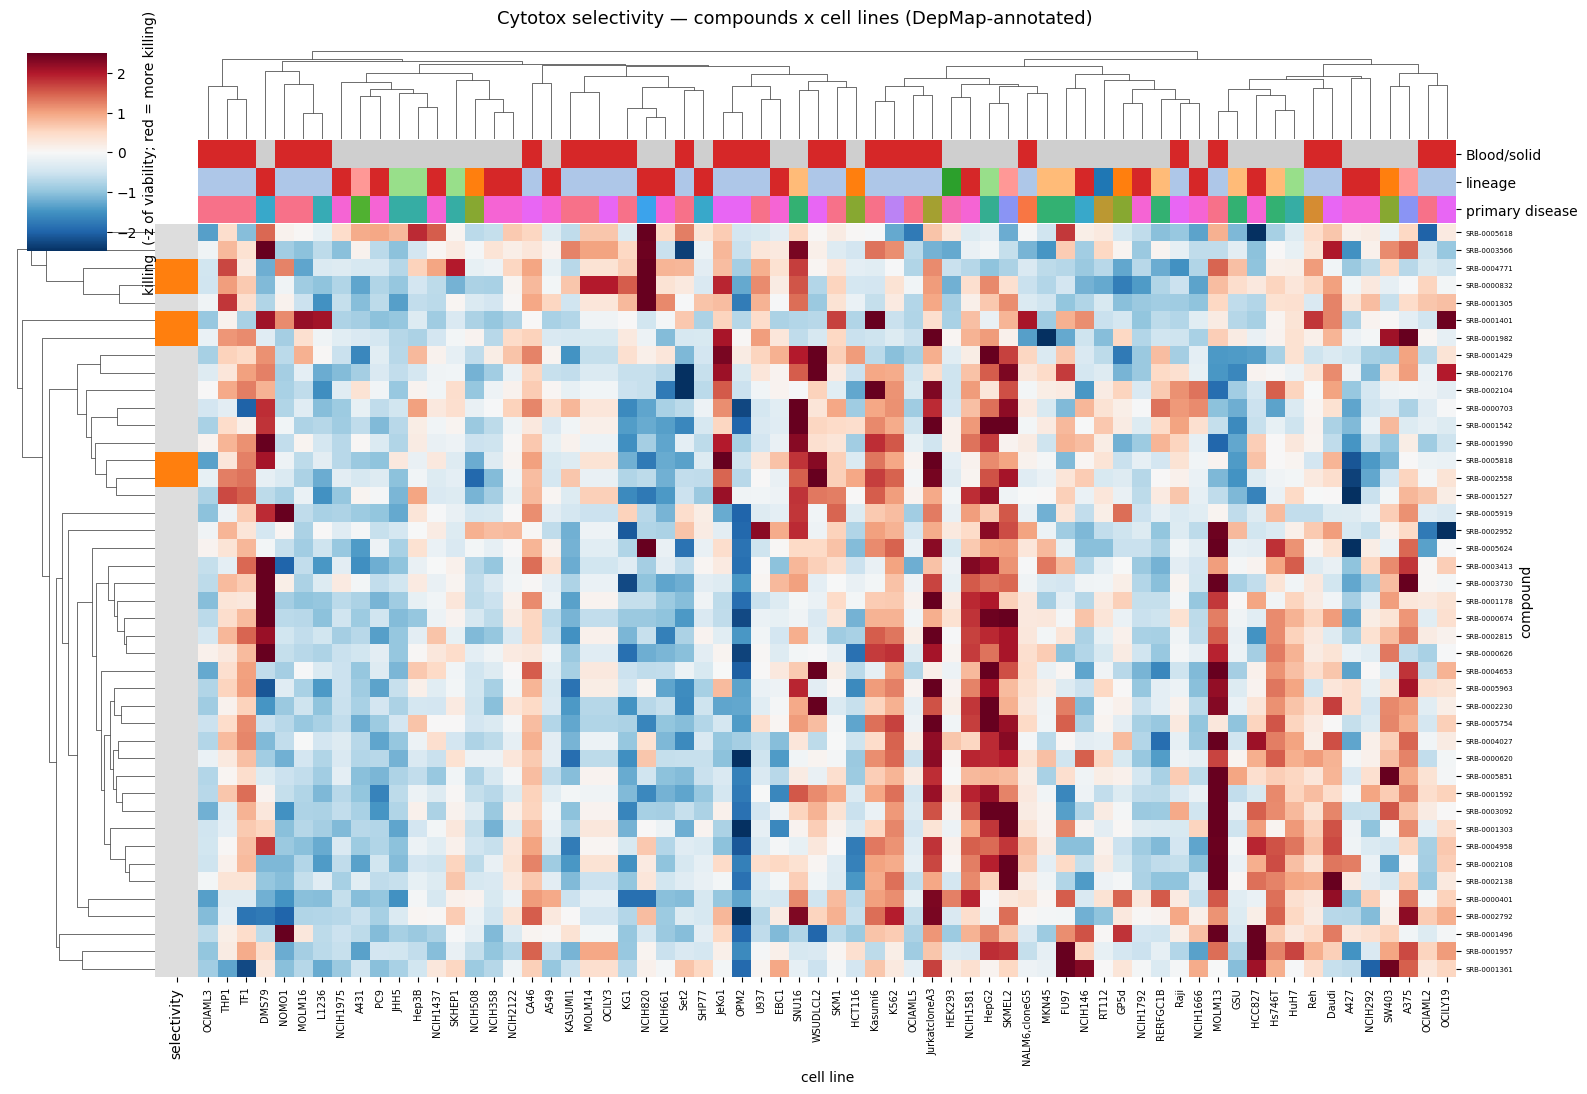

In [14]:
## Plot hierarchical clustering plot  (v3 — DepMap-annotated)
# Lower viability = more killing; ~100 = no effect. Cluster on PER-COMPOUND z-scores
# (selectivity, not potency), clip outliers, RED = killing. Column tracks now carry
# DepMap 24Q4 annotations (primary disease) on top of Blood-vs-solid.
# NOTE: rigorously, none of these sharpen the clustering beyond Blood/solid (perm-test);
# they are here for interpretability.

# --- config ---
TOP_SELECTIVE = None # 20       # None = all compounds; int K = keep only the K most selective (de-noises)
CLIP_Z        = 2.5      # clip z-scores to +/-CLIP_Z so outliers do not dominate colours
SEL_THRESH    = 5.0      # % killing diff (Blood - solid) to call a compound lineage-selective
FIGSIZE       = (16, 11)

# 1) viability matrix (compounds x cell lines); lower = more killing
mat = sig.set_index('compound').apply(pd.to_numeric, errors='coerce')
mat = mat.apply(lambda c: c.fillna(c.mean()))

# 2) keep most SELECTIVE compounds (cross-cell-line spread carries the signal)
sel_order = mat.std(axis=1).sort_values(ascending=False)
if TOP_SELECTIVE:
    mat = mat.loc[sel_order.head(TOP_SELECTIVE).index]

# 3) per-compound z-score (selectivity); clip; flip sign so RED = killing
z = mat.sub(mat.mean(1), axis=0).div(mat.std(1) + 1e-9, axis=0).clip(-CLIP_Z, CLIP_Z)
z = -z

# 4) cell-line column annotations (from DepMap-enriched cinfo)
ci    = cinfo.set_index('CellLineName').reindex(z.columns)
lin   = ci['Onco tree Lineage']
sub   = ci['Oncotree Primary Disease']
blood = np.where(lin.eq('Blood'), 'Blood', 'solid')
lin_u = sorted(lin.dropna().unique()); sub_u = sorted(sub.dropna().unique())
lin_pal   = dict(zip(lin_u, sns.color_palette('tab20', len(lin_u))))
sub_pal   = dict(zip(sub_u, sns.color_palette('husl', len(sub_u))))
blood_pal = {'Blood': '#d62728', 'solid': '#cfcfcf'}
col_colors = pd.DataFrame({
    'Blood/solid': pd.Series(blood, index=z.columns).map(blood_pal),
    'lineage'    : lin.map(lin_pal).fillna('#eeeeee'),
    'primary disease': sub.map(sub_pal).fillna('#ffffff'),
}, index=z.columns)

# 5) row annotation: per-compound Blood-selectivity = mean killing(Blood) - mean killing(solid)
kill      = 100 - mat
blood_sel = kill[z.columns[blood == 'Blood']].mean(1) - kill[z.columns[blood == 'solid']].mean(1)
bs_class  = pd.cut(blood_sel, [-np.inf, -SEL_THRESH, SEL_THRESH, np.inf],
                   labels=['solid-selective', 'non-selective', 'Blood-selective'])
bs_pal    = {'Blood-selective': '#ff7f0e', 'non-selective': '#dddddd', 'solid-selective': '#9467bd'}
row_colors = bs_class.astype(object).map(bs_pal); row_colors.name = 'selectivity'

# 6) clustermap — correlation distance, average linkage
g = sns.clustermap(
    z, cmap='RdBu_r', center=0, vmin=-CLIP_Z, vmax=CLIP_Z,
    col_colors=col_colors, row_colors=row_colors,
    metric='correlation', method='average',
    figsize=FIGSIZE, xticklabels=True, yticklabels=True,
    dendrogram_ratio=(0.10, 0.10),
    cbar_kws={'label': 'killing  (-z of viability; red = more killing)'},
)
g.ax_heatmap.set_xlabel('cell line'); g.ax_heatmap.set_ylabel('compound')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=5)
g.fig.suptitle('Cytotox selectivity — compounds x cell lines (DepMap-annotated)', y=1.02, fontsize=13)

# legends (primary disease omitted from legend — shown as a colour track)
h_blood = [Patch(facecolor=blood_pal[k], label=k) for k in ['Blood', 'solid']]
h_sel   = [Patch(facecolor=bs_pal[k], label=k) for k in ['Blood-selective','non-selective','solid-selective']]
h_lin   = [Patch(facecolor=lin_pal[l], label=l) for l in lin_u]
for handles, title, y in [(h_blood,'Blood/solid',1.00),
                          (h_sel,'compound selectivity',0.84), (h_lin,'lineage',0.66)]:
    a = g.ax_heatmap.legend(handles=handles, title=title, bbox_to_anchor=(1.30, y),
                            loc='upper left', frameon=False, fontsize=7)
    g.ax_heatmap.add_artist(a)
plt.show()


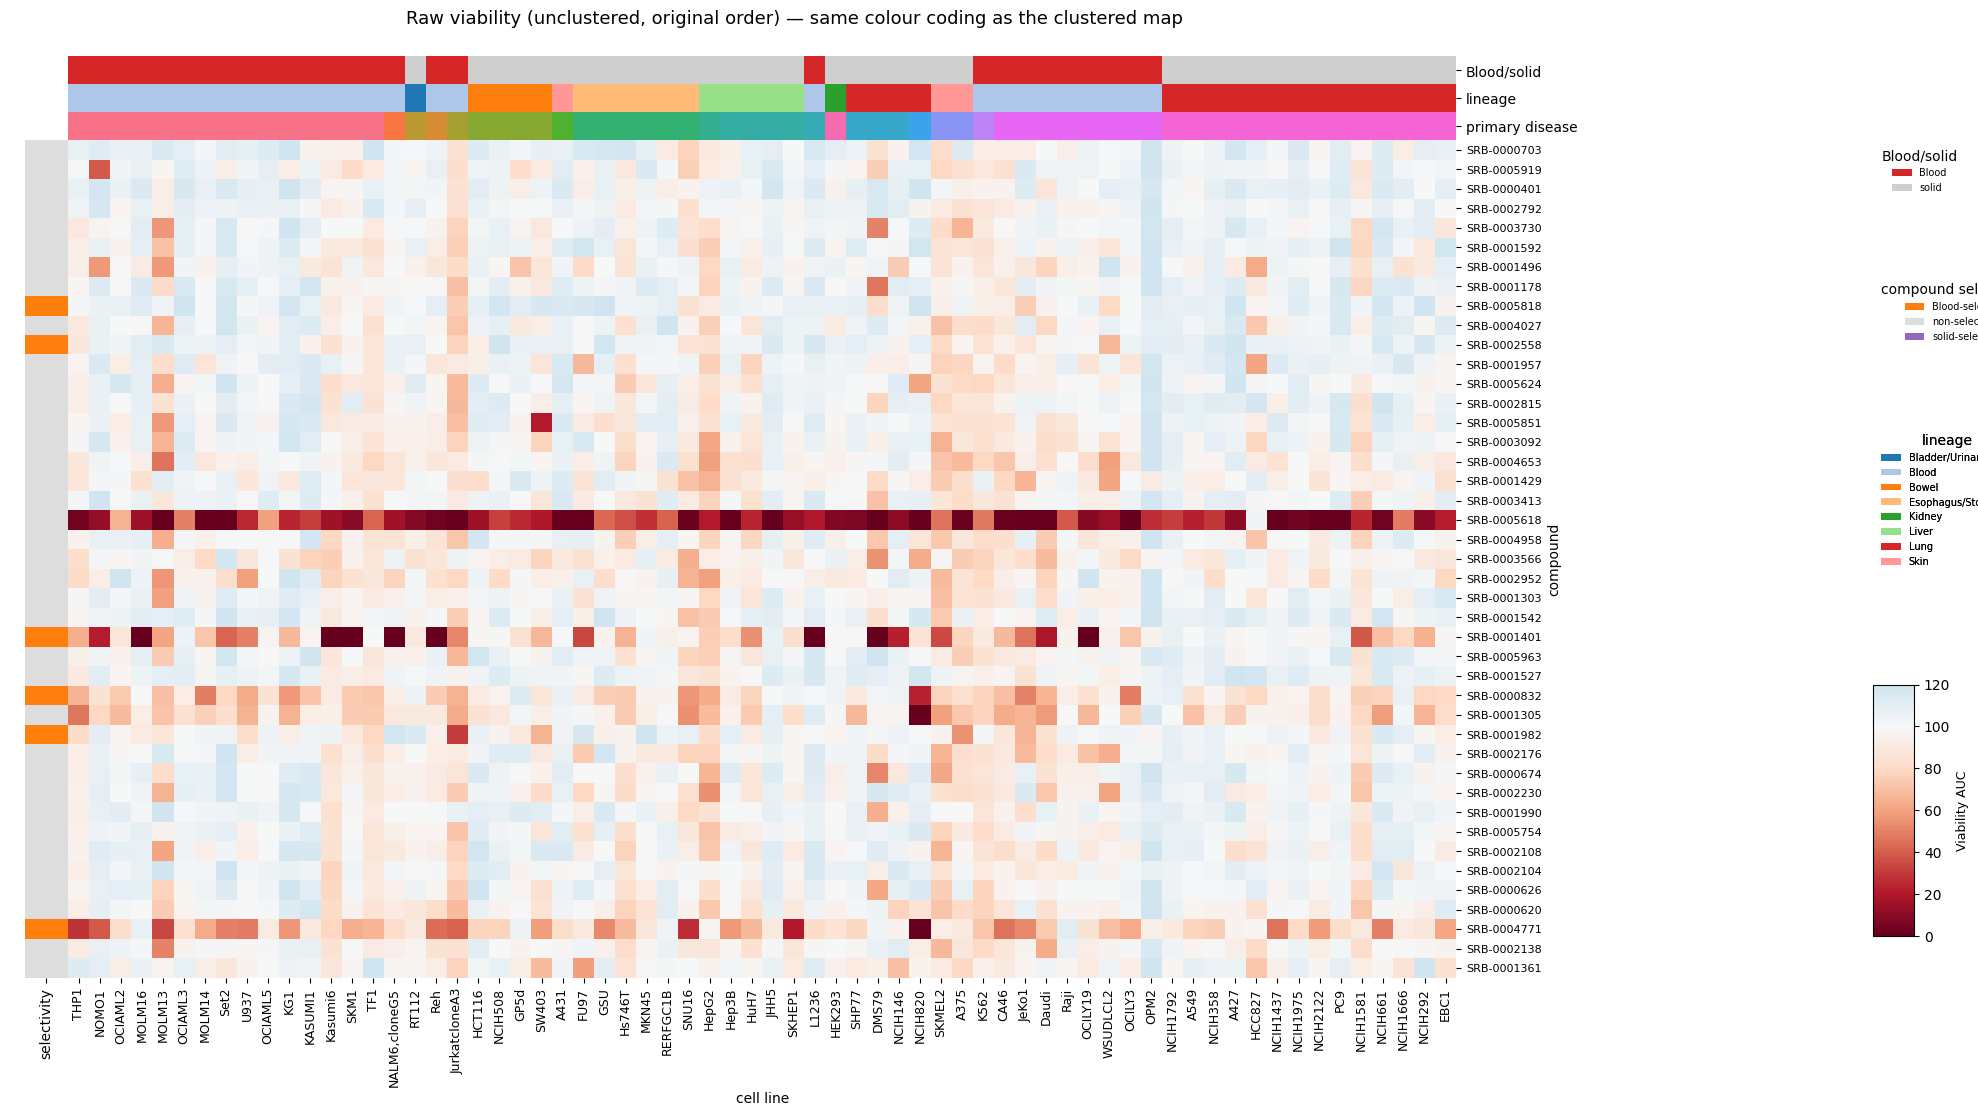

In [15]:
## Plot heatmap with raw data: SAME colour coding as the clustering-order cell
## (raw viability %, RdBu, centre=100, red=killing / blue=growth), but NOT clustered —
## rows (compounds) and columns (cell lines) stay in their original order, no dendrograms.
## Reuses mat / col_colors / row_colors from the clustermap cells above.
VMIN, VCENTER, VMAX = 0, 100, 120
g = sns.clustermap(
    mat,                                       # original order (mat = sig viability, compounds x cell lines)
    row_cluster=False, col_cluster=False,      # NO clustering
    cmap='RdBu', center=VCENTER, vmin=VMIN, vmax=VMAX,
    col_colors=col_colors, row_colors=row_colors,
    figsize=FIGSIZE, xticklabels=True, yticklabels=True,
    dendrogram_ratio=(0.01, 0.01),
    cbar_pos=None,                             # colourbar added below, to the RIGHT of the heatmap
)
g.ax_heatmap.set_xlabel('cell line'); g.ax_heatmap.set_ylabel('compound')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)
g.fig.suptitle('Raw viability (unclustered, original order) — same colour coding as the clustered map',
               y=1.02, fontsize=13)
for handles, title, yy in [(h_blood, 'Blood/solid', 1.00),
                           (h_sel,   'compound selectivity', 0.84),
                           (h_lin,   'lineage', 0.66)]:
    a = g.ax_heatmap.legend(handles=handles, title=title, bbox_to_anchor=(1.30, yy),
                            loc='upper left', frameon=False, fontsize=7)
    g.ax_heatmap.add_artist(a)

# colourbar to the RIGHT of the heatmap (axes-fraction coords -> never overlaps it),
# placed below the legends
cax = g.ax_heatmap.inset_axes([1.30, 0.05, 0.03, 0.30])
cb  = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cax)
cb.set_label('Viability AUC', fontsize=9)
plt.show()


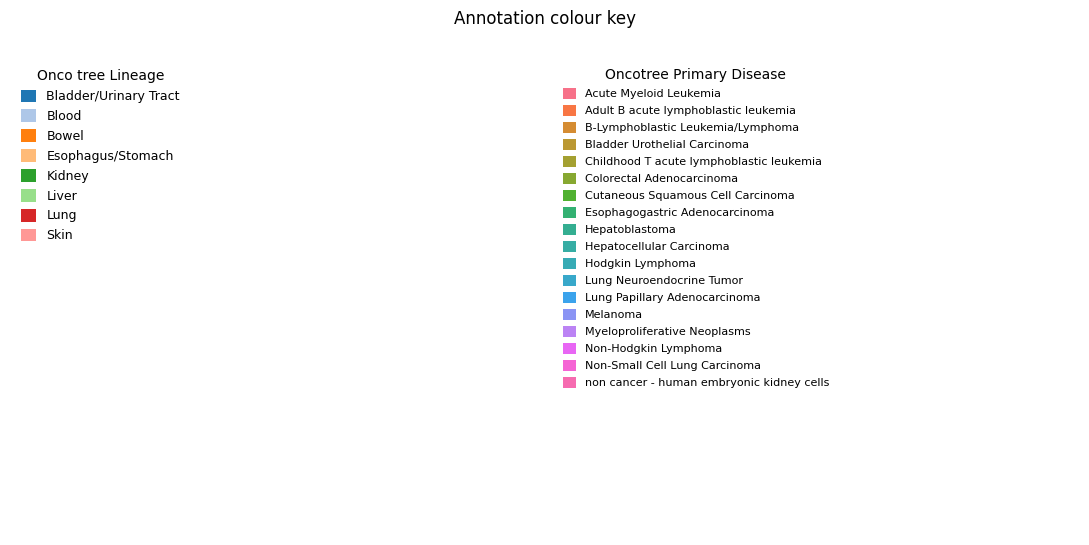

In [16]:
## Colour-key legends for the heatmap annotation tracks: lineage and primary disease.
## Self-contained — rebuilds lin_pal / sub_pal from cinfo with the SAME construction
## as the clustermap cell, so the swatch colours match the heatmap side-bars exactly.
_lin = cinfo.set_index('CellLineName')['Onco tree Lineage']
_sub = cinfo.set_index('CellLineName')['Oncotree Primary Disease']
lin_u = sorted(_lin.dropna().unique())
sub_u = sorted(_sub.dropna().unique())
lin_pal = dict(zip(lin_u, sns.color_palette('tab20', len(lin_u))))
sub_pal = dict(zip(sub_u, sns.color_palette('husl', len(sub_u))))

fig, axes = plt.subplots(1, 2, figsize=(11, max(4, len(sub_u) * 0.30)))
axes[0].legend(handles=[Patch(facecolor=lin_pal[l], label=l) for l in lin_u],
               title='Onco tree Lineage', loc='upper left', frameon=False, fontsize=9,
               handlelength=1.2, handleheight=1.2)
axes[0].axis('off')
axes[1].legend(handles=[Patch(facecolor=sub_pal[s], label=s) for s in sub_u],
               title='Oncotree Primary Disease', loc='upper left', frameon=False, fontsize=8,
               handlelength=1.2, handleheight=1.2)
axes[1].axis('off')
fig.suptitle('Annotation colour key', y=1.0, fontsize=12)
plt.tight_layout(); plt.show()


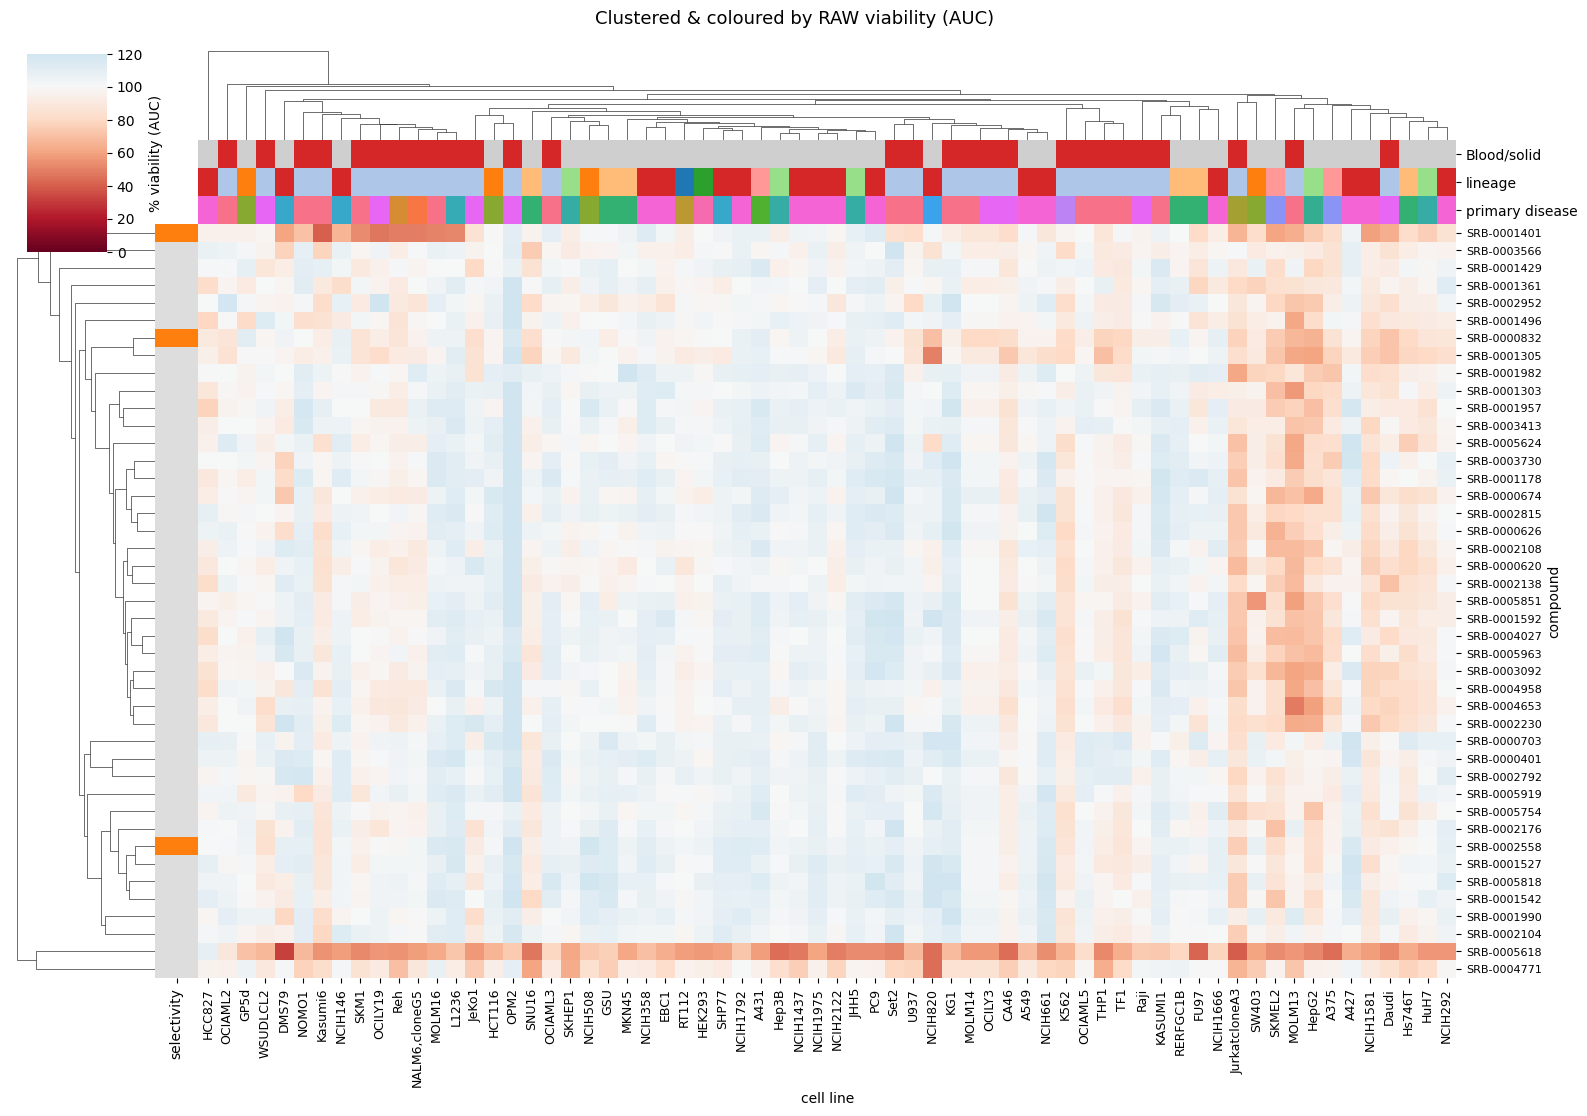

In [21]:
## Clustered AND coloured by RAW viability (AUC) — correlation-distance hierarchical
## clustering on the raw viability matrix (not the per-compound z). Compounds and cell
## lines are grouped by their absolute response profiles. Reuses mat / annotations above.
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

# linkages from the RAW VIABILITY matrix (correlation distance)
row_link = linkage(pdist(mat.values,   metric='correlation'), method='average')   # compounds
col_link = linkage(pdist(mat.T.values, metric='correlation'), method='average')   # cell lines

# colour by RAW viability: low = killing = RED, ~100 = no effect = white, >100 = growth = BLUE
VMIN, VCENTER, VMAX = 0, 100, 120
g = sns.clustermap(
    mat, row_linkage=row_link, col_linkage=col_link,
    cmap='RdBu', center=VCENTER, vmin=VMIN, vmax=VMAX,
    col_colors=col_colors, row_colors=row_colors,
    metric='correlation', method='average',          # ignored (linkages given) but kept for clarity
    figsize=FIGSIZE, xticklabels=True, yticklabels=True,
    dendrogram_ratio=(0.10, 0.10),
    cbar_kws={'label': '% viability (AUC)'},
)
g.ax_heatmap.set_xlabel('cell line'); g.ax_heatmap.set_ylabel('compound')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)
g.fig.suptitle('Clustered & coloured by RAW viability (AUC)',
               y=1.02, fontsize=13)

# reuse the legends built in the cell above (Blood/solid, selectivity, lineage)
for handles, title, yy in [(h_blood, 'Blood/solid', 1.00),
                           (h_sel,   'compound selectivity', 0.84),
                           (h_lin,   'lineage', 0.66)]:
    a = g.ax_heatmap.legend(handles=handles, title=title, bbox_to_anchor=(1.30, yy),
                            loc='upper left', frameon=False, fontsize=7)
    g.ax_heatmap.add_artist(a)
plt.show()




> 43 compounds clustered by Tanimoto (of 43 in the heatmap)


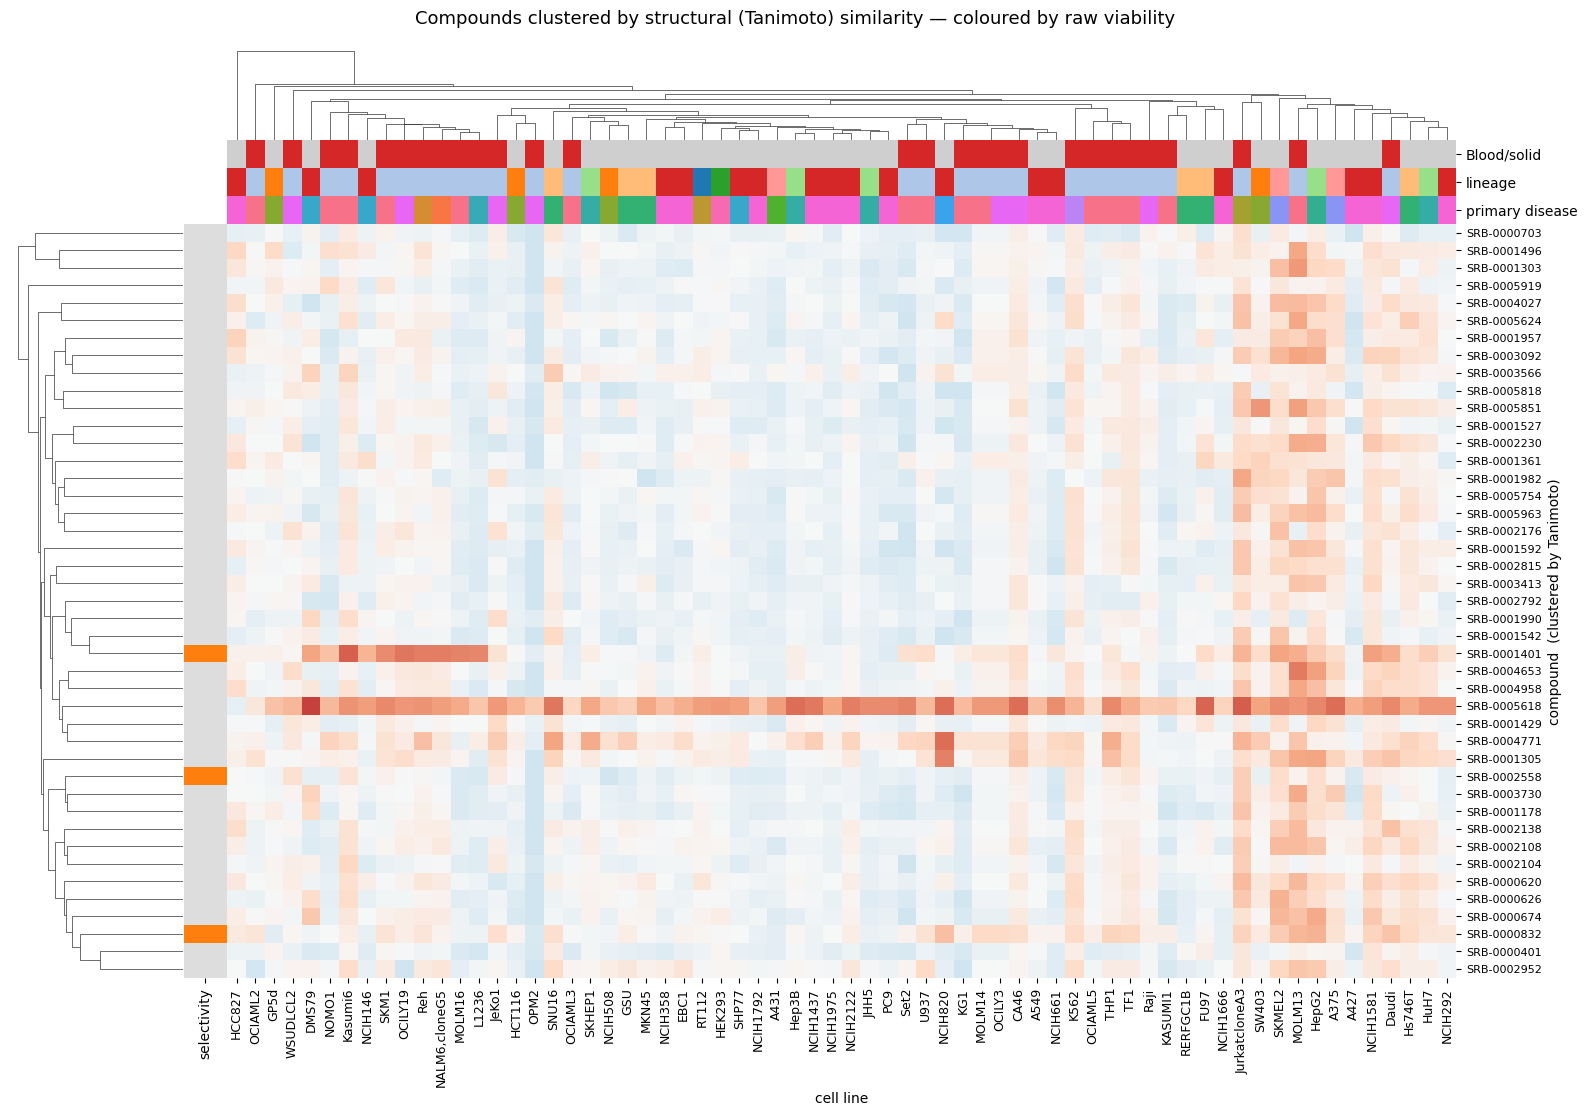

In [23]:
## compound clustering by structural similarity:
## Cluster COMPOUNDS (rows) by Tanimoto similarity (Morgan FP) instead of by viability,
## then colour cells by raw viability. Reveals whether structurally-similar compounds
## (now grouped as horizontal blocks) share a viability pattern — the visual companion
## to the Mantel test. Cell lines (columns) still clustered by viability correlation.
## Reuses mat / col_colors / row_colors / MF from the cells above.
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform, pdist
import Rdkit_tools as rdkit_tools

# heatmap compounds present in the Morgan-FP table
mf_compounds = set(MF['compound'])
compounds    = [c for c in mat.index if c in mf_compounds]
mat_h        = mat.loc[compounds]
row_colors_h = row_colors.reindex(compounds)
print(f'> {len(compounds)} compounds clustered by Tanimoto (of {mat.shape[0]} in the heatmap)')

# Tanimoto distance among these compounds (Morgan FP) -> row linkage
MF_sub = MF.drop_duplicates('compound').set_index('compound').loc[compounds].reset_index()
Dc = rdkit_tools.get_RDKiTTanimoto_distance_matrix(MF_sub, MF_sub).loc[compounds, compounds].values
Dc = (Dc + Dc.T) / 2.0; np.fill_diagonal(Dc, 0.0)                  # enforce symmetry + zero diag
row_link = linkage(squareform(Dc, checks=False), method='average')  # compounds by STRUCTURE

# cell lines (columns) clustered by viability correlation (as before)
col_link = linkage(pdist(mat_h.T.values, metric='correlation'), method='average')

VMIN, VCENTER, VMAX = 0, 100, 120
g = sns.clustermap(
    mat_h, row_linkage=row_link, col_linkage=col_link,
    cmap='RdBu', center=VCENTER, vmin=VMIN, vmax=VMAX,
    col_colors=col_colors, row_colors=row_colors_h,
    figsize=FIGSIZE, xticklabels=True, yticklabels=True,
    dendrogram_ratio=(0.12, 0.10),
    cbar_pos=None,
)
g.ax_heatmap.set_xlabel('cell line'); g.ax_heatmap.set_ylabel('compound  (clustered by Tanimoto)')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)
g.fig.suptitle('Compounds clustered by structural (Tanimoto) similarity — coloured by raw viability',
               y=1.02, fontsize=13)
for handles, title, yy in [(h_blood, 'Blood/solid', 1.00),
                           (h_sel,   'compound selectivity', 0.84),
                           (h_lin,   'lineage', 0.66)]:
    a = g.ax_heatmap.legend(handles=handles, title=title, bbox_to_anchor=(1.30, yy),
                            loc='upper left', frameon=False, fontsize=7)
    g.ax_heatmap.add_artist(a)
plt.show()


> 43 compounds in both FP and cytotox

=== Mantel (Tanimoto similarity vs activity Spearman) ===
  activity = raw viability        rho=+0.071  perm p=0.2329  -> no significant structure-activity link
  activity = z-scored viability   rho=+0.032  perm p=0.1234  -> no significant structure-activity link


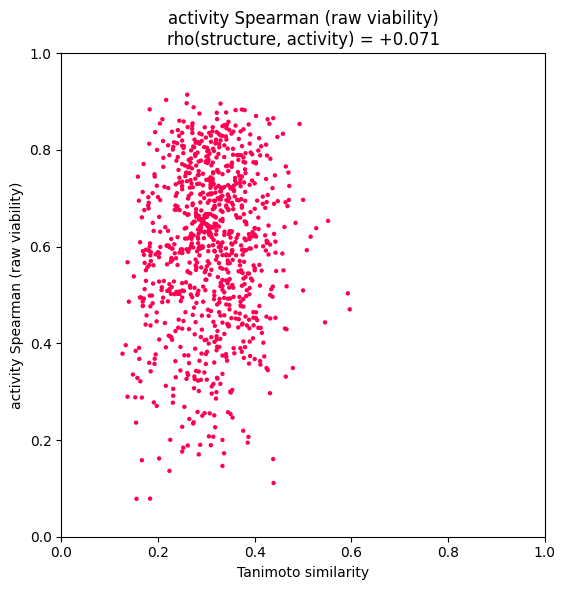


> 0 close-analogue pairs (Tanimoto > 0.7)
> pairs ranked by structure-similar / activity-discordant saved to output/cytotox/sar_cliffs.csv


In [157]:
## Mantel test — do structurally similar compounds have similar antiproliferative activity?
## Each point = a compound PAIR. x = Tanimoto similarity (structural; >0.7 = close analogues),
## y = Spearman correlation of the two compounds' cytotox profiles across cell lines (activity
## similarity). Continuous SAR -> dots trend UP (similar structure => correlated activity).
## Two y-views: (1) raw viability, (2) per-cell-line z-scored viability (removes the
## "some cell lines just die more" baseline). Significance = permutation (Mantel) p-value.
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, rankdata
rng = np.random.default_rng(0)

# --- align compound set present in BOTH the FP table (MF) and the cytotox matrix (sig) ---
sig_mat   = sig.set_index('compound').apply(pd.to_numeric, errors='coerce')
sig_mat   = sig_mat.apply(lambda col: col.fillna(col.mean()))
MF_u      = MF.drop_duplicates('compound')
compounds = sorted(set(MF_u['compound']) & set(sig_mat.index))
print(f'> {len(compounds)} compounds in both FP and cytotox')

# --- structural Tanimoto SIMILARITY (Morgan FP), aligned ---
MF_aln = MF_u.set_index('compound').loc[compounds].reset_index()
Ds  = rdkit_tools.get_RDKiTTanimoto_distance_matrix(MF_aln, MF_aln).loc[compounds, compounds].values
sim = 1 - Ds                                              # Tanimoto similarity

# --- pairwise activity SIMILARITY = Spearman corr between compounds' profiles ---
A  = sig_mat.loc[compounds]                               # compounds x cell lines (viability)
Az = (A - A.mean(0)) / (A.std(0) + 1e-9)                  # z per cell line (remove baseline)
def pairwise_spearman(M):                                 # rank within each compound, then Pearson = Spearman
    R = np.apply_along_axis(rankdata, 1, np.asarray(M))
    return np.corrcoef(R)
S_raw = pairwise_spearman(A.values)                       # activity corr, raw viability
S_z   = pairwise_spearman(Az.values)                      # activity corr, z-scored viability

# --- Mantel test: structural similarity vs activity correlation (permutation p) ---
iu = np.triu_indices(len(compounds), k=1)
def mantel(sim_mat, act_mat, n_perm=9999):
    obs  = spearmanr(sim_mat[iu], act_mat[iu]).correlation
    null = np.empty(n_perm)
    for k in range(n_perm):
        p = rng.permutation(len(compounds))
        null[k] = spearmanr(sim_mat[iu], act_mat[p][:, p][iu]).correlation
    return obs, (1 + np.sum(null >= obs)) / (1 + n_perm)

print('\n=== Mantel (Tanimoto similarity vs activity Spearman) ===')
for name, S in [('activity = raw viability', S_raw), ('activity = z-scored viability', S_z)]:
    rho, pval = mantel(sim, S)
    verdict = 'SAR continuous' if (rho > 0 and pval < 0.05) else 'no significant structure-activity link'
    print(f'  {name:30s}  rho={rho:+.3f}  perm p={pval:.4f}  -> {verdict}')
    hi = S[iu][sim[iu] > 0.7]
    if len(hi):
        print(f'      mean activity-corr for Tanimoto>0.7 pairs: {hi.mean():+.3f} (n={len(hi)})')

# --- Graph 1: Tanimoto similarity vs activity Spearman (RAW viability) ---
def _scatter(S, ylab):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(sim[iu], S[iu], s=10, alpha=1.0, color=silent_c, edgecolor='none')
    ax.axhline(0, color='grey', lw=0.6)
    rho = spearmanr(sim[iu], S[iu]).correlation
    ax.set_xlabel('Tanimoto similarity'); ax.set_ylabel(ylab)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')   # square [0,1] box
    ax.set_title(f'{ylab}\nrho(structure, activity) = {rho:+.3f}')
    plt.tight_layout(); plt.show()

_scatter(S_raw, 'activity Spearman (raw viability)')

# --- structurally-similar-but-activity-discordant pairs; save (don't echo IDs) ---
discord = sim * (1 - S_raw)                               # high = close structure, uncorrelated activity
cliffs = (pd.DataFrame({'compound_a': [compounds[a] for a in iu[0]],
                        'compound_b': [compounds[b] for b in iu[1]],
                        'tanimoto_sim': sim[iu], 'activity_spearman_raw': S_raw[iu],
                        'activity_spearman_z': S_z[iu], 'discordance': discord[iu]})
          .sort_values('discordance', ascending=False).reset_index(drop=True))
cliffs.to_csv('output/cytotox/sar_cliffs.csv', index=False)
print(f'\n> {(sim[iu] > 0.7).sum()} close-analogue pairs (Tanimoto > 0.7)')
print(f'> pairs ranked by structure-similar / activity-discordant saved to output/cytotox/sar_cliffs.csv')


> Blood: 28 cell lines | solid: 38 cell lines


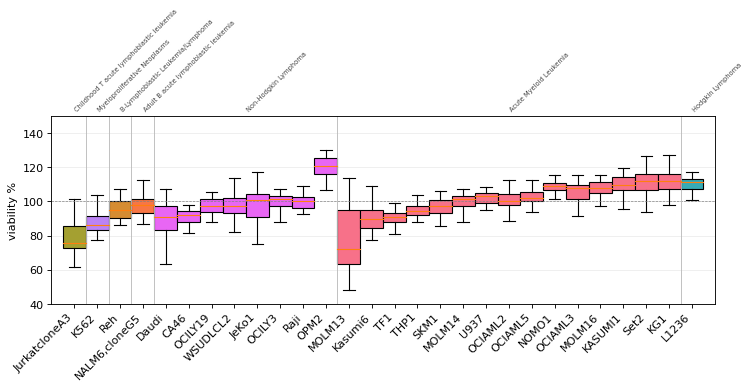

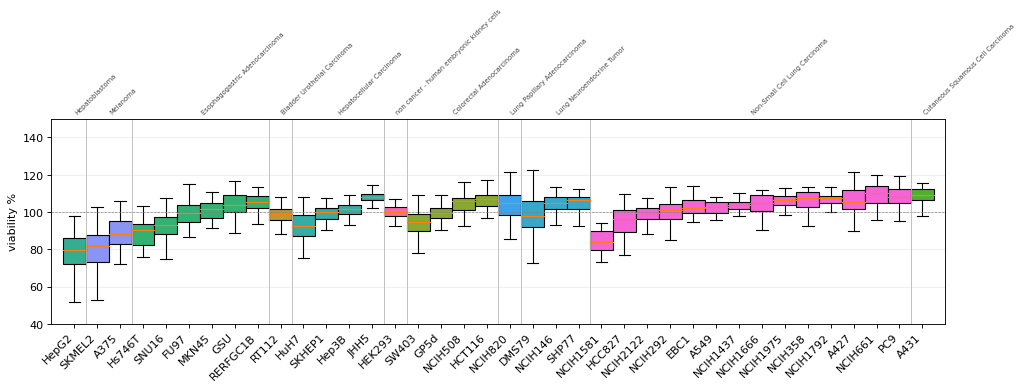

In [158]:
## Same primary-disease-grouped viability boxplots, but SPLIT by Blood vs solid lineage.
## Two figures (Blood-lineage cell lines, then solid). Within each: group by primary disease
## (groups by descending group-mean sensitivity) and order cells by descending
## sensitivity. Raw viability % on y. Reuses mat / cinfo / sub_pal from above.
_lin = cinfo.set_index('CellLineName')['Onco tree Lineage']
_sub = cinfo.set_index('CellLineName')['Oncotree Primary Disease']
_kill = 100 - mat

def _grouped_viability_box(cells, label):
    tbl = pd.DataFrame({'cell': cells})
    tbl['disease']   = tbl['cell'].map(_sub).fillna('(unknown)')
    tbl['mean_kill'] = tbl['cell'].map(_kill.mean(0))
    gmean = tbl.groupby('disease')['mean_kill'].mean().sort_values(ascending=False)
    ordered, sizes = [], []
    for s in gmean.index:
        block = tbl[tbl['disease'] == s].sort_values('mean_kill', ascending=False)['cell'].tolist()
        ordered += block; sizes.append((s, len(block)))
    data   = [mat[c].dropna().values for c in ordered]
    colors = [sub_pal.get(_sub.get(c), '#dddddd') for c in ordered]
    stats_tools.plot_nice_boxplot(data, titles=ordered, colors=colors,
                                  notch=False, show_N=False,
                                  height=5, width=max(8, len(ordered) * 0.34))
    ax = plt.gca()
    plt.ylabel('viability %'); plt.axhline(100, color='grey', lw=0.6, ls='--')
    _i = 0
    for s, n in sizes:
        if _i > 0:
            ax.axvline(1 + (_i - 0.5) * 0.5, color='#bbbbbb', lw=0.8)
        ax.text(1 + (_i + (n - 1) / 2) * 0.5, 1.02, s, transform=ax.get_xaxis_transform(),
                rotation=45, ha='left', va='bottom', fontsize=6, color='#444')
        _i += n
    ax.set_ylim(40, 150)                       # fixed y-range for cross-panel comparison
    ax.set_yticks(np.arange(40, 151, 20))      # horizontal grid every 20
    ax.yaxis.grid(True, color='#EEEEEE'); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()

_blood = [c for c in mat.columns if _lin.get(c) == 'Blood']
_solid = [c for c in mat.columns if _lin.get(c) != 'Blood']
print(f'> Blood: {len(_blood)} cell lines | solid: {len(_solid)} cell lines')
_grouped_viability_box(_blood, 'Blood')
_grouped_viability_box(_solid, 'solid')


In [121]:
## COMPARE-style mechanism nomination — GDSC reference (supersedes the PRISM attempt:
## PRISM only shared 22 cell lines with our blood-heavy panel and gave noise-floor results).
## GDSC2 shares ~49 of our 66 cell lines and annotates each drug with a TARGET PATHWAY.
## For each of OUR compounds we correlate its cytotox fingerprint against every GDSC drug's
## sensitivity profile over the shared cell lines; the top-correlated drugs' pathways nominate
## a mechanism. A permutation NULL CHECK tells us if the correlations beat chance.
## Cell-line / drug / pathway names are public; our compound IDs stay local (saved to disk).
import re
GDSC='data/external/gdsc/'; TOP_K=25
rng = np.random.default_rng(0)
_norm = lambda x: re.sub(r'[^A-Z0-9]', '', str(x).upper())

# --- our killing fingerprints (compounds x cell lines) ---
our = sig.set_index('compound').apply(pd.to_numeric, errors='coerce')
our = our.apply(lambda col: col.fillna(col.mean()))
our_norm2name = {_norm(cl): cl for cl in our.columns}

# --- GDSC reference: AUC matrix (cell lines x DRUG_ID) + drug -> pathway ---
gdsc = pd.read_csv(GDSC+'gdsc_auc_matrix.csv', index_col=0)          # rows = CELL_LINE_NAME
gdsc.columns = gdsc.columns.astype(int)                              # DRUG_ID int (match dinfo index)
dinfo = pd.read_csv(GDSC+'gdsc_drug_info.csv', index_col=0)          # DRUG_ID -> name/pathway/target
gdsc_norm = {_norm(cl): cl for cl in gdsc.index}

# --- shared cell lines (matched by normalised name) ---
shared = sorted(set(our_norm2name) & set(gdsc_norm))
our_cols  = [our_norm2name[k] for k in shared]
gdsc_rows = [gdsc_norm[k]      for k in shared]
print(f'> shared cell lines (our panel ∩ GDSC): {len(shared)}  (of {our.shape[1]} ours)')

# --- mean-centred, L2-normalised KILLING matrices over shared lines (COMPARE delta) ---
def _prep(M):
    M = M - np.nanmean(M, axis=1, keepdims=True)
    M = np.nan_to_num(M)
    n = np.linalg.norm(M, axis=1, keepdims=True); n[n == 0] = 1
    return M / n

Q = _prep((100 - our[our_cols]).values)                              # our killing, n_ours x shared
P_raw = (-gdsc.loc[gdsc_rows].T)                                      # GDSC killing (-AUC), drugs x shared
keep  = np.isfinite(P_raw.values).sum(1) >= max(15, int(0.8*len(shared)))
P_raw = P_raw[keep]; P = _prep(P_raw.values)
drug_ids = P_raw.index.to_numpy()
print(f'> GDSC drugs with enough data over shared lines: {len(drug_ids)} / {gdsc.shape[1]}')

R = Q @ P.T                                                          # n_ours x n_drugs  Pearson r

# --- NULL check: shuffle shared-line order, recompute median top-K mean r ---
def med_topk(Rm): return float(np.median([np.sort(Rm[i])[::-1][:TOP_K].mean() for i in range(Rm.shape[0])]))
obs = med_topk(R)
null = np.array([med_topk(Q @ P[:, rng.permutation(P.shape[1])].T) for _ in range(30)])
clears = obs > null.mean() + 2*null.std()
print(f'\n> median top-{TOP_K} r: observed={obs:.3f}  null={null.mean():.3f}+/-{null.std():.3f}  '
      f'-> {"ABOVE noise" if clears else "at noise floor (nominations not reliable)"}')

# --- per-compound pathway nomination (top-K drugs -> majority TARGET_PATHWAY) ---
path = dinfo['PATHWAY_NAME']
rows = []
for i, comp in enumerate(our.index):
    order = np.argsort(R[i])[::-1][:TOP_K]
    tp = path.reindex(drug_ids[order]).dropna()
    tp = tp[~tp.isin(['Unclassified', 'Other'])]                     # ignore non-informative buckets
    nom = tp.value_counts()
    rows.append({'compound': comp,
                 'nominated_pathway': nom.index[0] if len(nom) else None,
                 'support': int(nom.iloc[0]) if len(nom) else 0,
                 'support_frac': round(nom.iloc[0]/TOP_K, 2) if len(nom) else 0,
                 'top_mean_r': round(float(R[i][order].mean()), 3),
                 'top_drugs': '; '.join(dinfo['DRUG_NAME'].reindex(drug_ids[order]).dropna().unique()[:5])})
nom_df = pd.DataFrame(rows).sort_values('support', ascending=False).reset_index(drop=True)
nom_df.to_csv('output/cytotox/compare_moa_nominations_gdsc.csv', index=False)

print(f'> per-compound pathway nominations saved to output/cytotox/compare_moa_nominations_gdsc.csv')
print(f'\n=== most frequently nominated GDSC target pathways across our {len(nom_df)} compounds ===')
print(nom_df['nominated_pathway'].value_counts().head(12).to_string())


> shared cell lines (our panel ∩ GDSC): 50  (of 66 ours)
> GDSC drugs with enough data over shared lines: 166 / 295

> median top-25 r: observed=0.209  null=0.199+/-0.047  -> at noise floor (nominations not reliable)
> per-compound pathway nominations saved to output/cytotox/compare_moa_nominations_gdsc.csv

=== most frequently nominated GDSC target pathways across our 43 compounds ===
nominated_pathway
DNA replication                      14
Genome integrity                     13
Other, kinases                        5
ERK MAPK signaling                    2
Cell cycle                            2
Protein stability and degradation     2
Apoptosis regulation                  2
RTK signaling                         1
PI3K/MTOR signaling                   1
Hormone-related                       1


#### 0.3 Machine Learning to predict cell signatures from transcriptomics

In [19]:
expr = pd.read_parquet('output/cytotox/expr_ourlines.parquet')   # cell lines x 19,193 genes

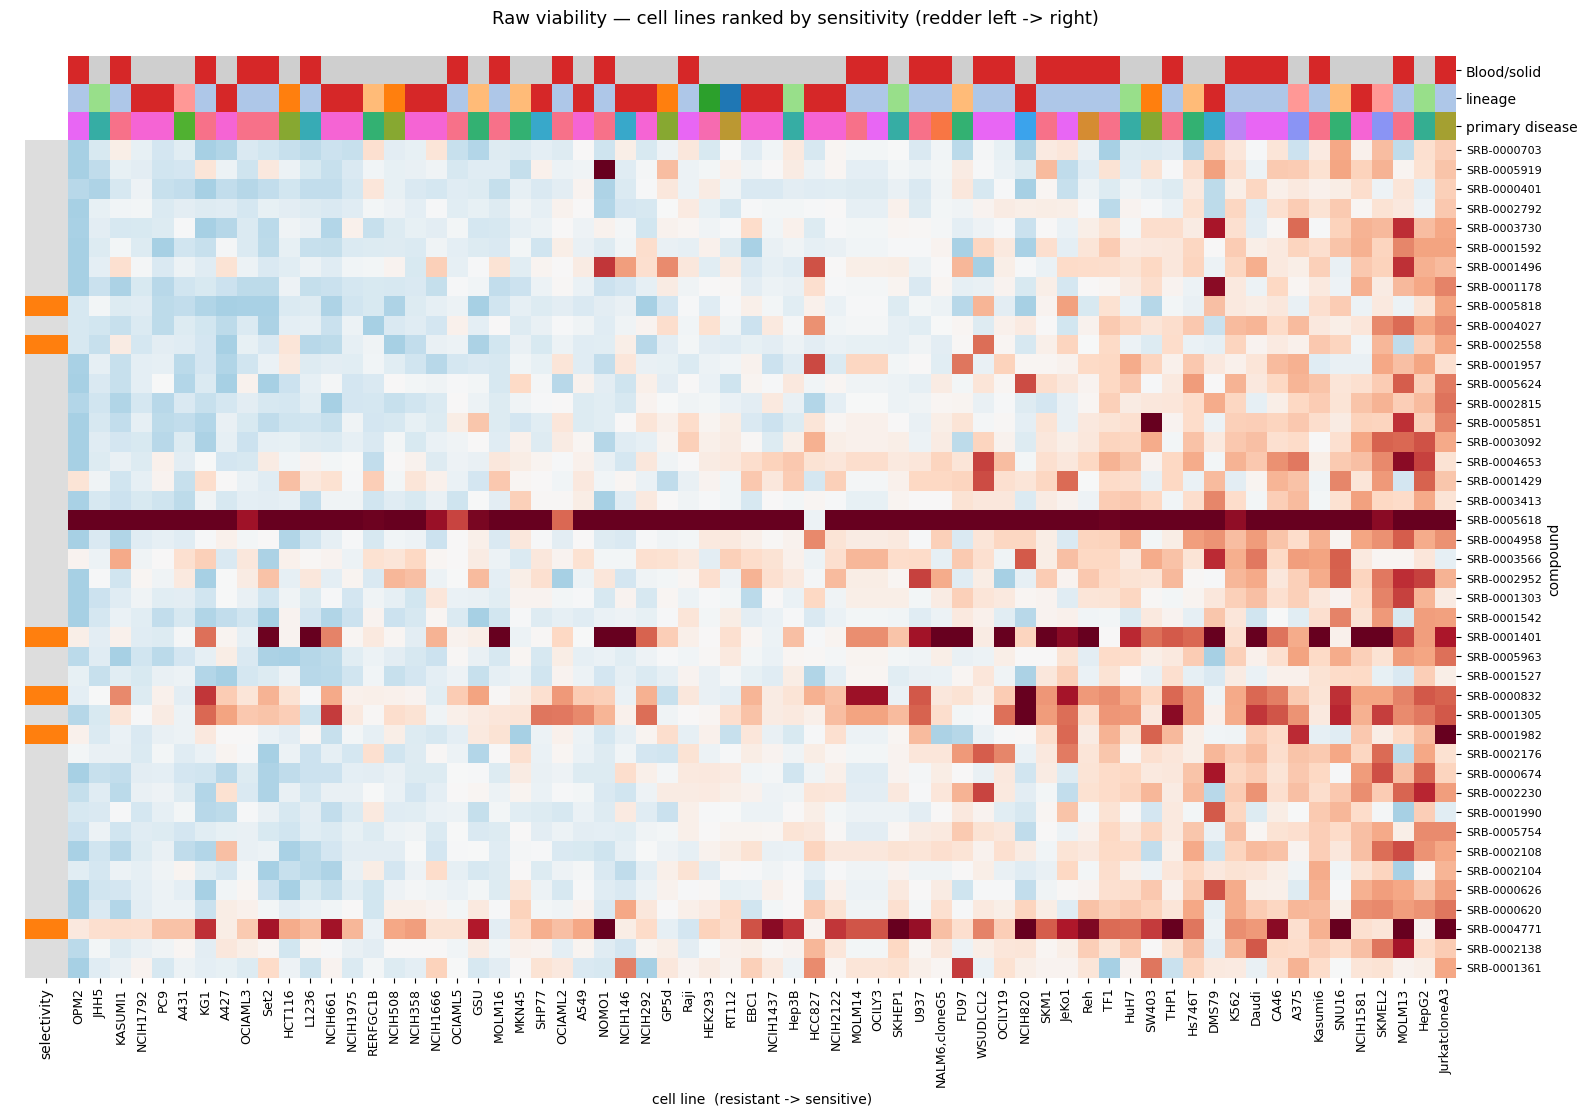

In [17]:
## show cellines lines heatmap ranked by sensitivity
## Same raw-viability heatmap as the unclustered cell, but cell lines (columns) are
## SORTED by sensitivity (mean killing across compounds, ascending) -> the map gets
## redder left -> right (resistant on the left, most-sensitive on the right).
## Reuses mat / col_colors / row_colors from the clustermap cells above.
VMIN, VCENTER, VMAX = 40, 100, 120

# rank cell lines by sensitivity = mean killing across compounds (ascending -> red rightward)
cell_order = (100 - mat).mean(axis=0).sort_values(ascending=True).index
mat_s      = mat[cell_order]
col_s      = col_colors.reindex(cell_order)          # keep annotation tracks aligned

g = sns.clustermap(
    mat_s,
    row_cluster=False, col_cluster=False,            # no clustering — explicit sensitivity order
    cmap='RdBu', center=VCENTER, vmin=VMIN, vmax=VMAX,
    col_colors=col_s, row_colors=row_colors,
    figsize=FIGSIZE, xticklabels=True, yticklabels=True,
    dendrogram_ratio=(0.01, 0.01),
    cbar_pos=None,
)
g.ax_heatmap.set_xlabel('cell line  (resistant -> sensitive)'); g.ax_heatmap.set_ylabel('compound')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)
g.fig.suptitle('Raw viability — cell lines ranked by sensitivity (redder left -> right)',
               y=1.02, fontsize=13)
for handles, title, yy in [(h_blood, 'Blood/solid', 1.00),
                           (h_sel,   'compound selectivity', 0.84),
                           (h_lin,   'lineage', 0.66)]:
    a = g.ax_heatmap.legend(handles=handles, title=title, bbox_to_anchor=(1.30, yy),
                            loc='upper left', frameon=False, fontsize=7)
    g.ax_heatmap.add_artist(a)
plt.show()


In [96]:
## Split cell lines between sensitive and resistant (binarize — TERTILE split).
# 1) drop the pan-killer compound (kills everything -> dominates the per-cell-line mean)
mat = sig.set_index('compound').apply(pd.to_numeric, errors='coerce')
# DROP_COMPOUNDS = ['SRB-0005618']
# mat = mat.drop(index=[c for c in DROP_COMPOUNDS if c in mat.index])
print(f'> dropped {DROP_COMPOUNDS}: {mat.shape[0]} compounds x {mat.shape[1]} cell lines remain')

# 2) per-cell-line general sensitivity = mean killing across compounds (higher = more sensitive)
sens = (100 - mat).mean(axis=0).sort_values(ascending=False)

# 3) TERTILE split: top third = sensitive, bottom third = resistant, AMBIGUOUS MIDDLE DROPPED
#    (sharpens the contrast vs a median split — standard CCLE-style discretisation)
lo, hi = sens.quantile([1/3,2/3])
label = pd.Series(index=sens.index, dtype=object, name='group')
label[sens >= hi] = 'sensitive'
label[sens <= lo] = 'resistant'
label = label.dropna()                       # drop the middle third
print(f'> tertile cuts: resistant <= {lo:.2f}  |  sensitive >= {hi:.2f}')
print(f'> sensitive {int((label=="sensitive").sum())} | resistant {int((label=="resistant").sum())} '
      f'| middle dropped {sens.shape[0]-label.shape[0]}')
label.value_counts()


> dropped ['SRB-0005618']: 43 compounds x 66 cell lines remain
> tertile cuts: resistant <= 0.89  |  sensitive >= 8.71
> sensitive 22 | resistant 22 | middle dropped 22


group
sensitive    22
resistant    22
Name: count, dtype: int64

> matched 42 cell lines (of 44 labelled): resistant n=22 | sensitive n=20
> median FBXO31  resistant=3.65  sensitive=3.80
> Mann-Whitney (sensitive > resistant): U=227, p=0.435


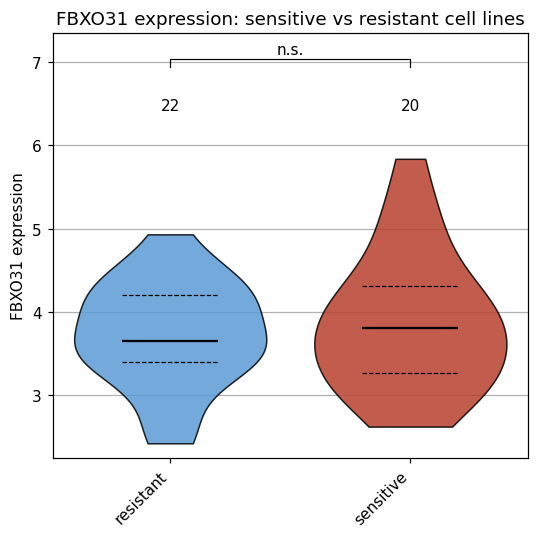

In [97]:
## Box plot showing sensitivity per cell line vs FBXO31 expression
## Violin plot: FBXO31 expression (y) in sensitive vs resistant cell lines (x), using the
## tertile sensitivity `label` from above. Question: do SENSITIVE lines express MORE FBXO31
## than resistant ones? -> one-sided Mann-Whitney (printed) + significance bracket on the plot.
from scipy.stats import mannwhitneyu

# FBXO31 expression per cell line, joined to the sensitive/resistant label (inner join)
df_v = pd.DataFrame({'FBXO31': expr['FBXO31']}).join(label, how='inner').dropna()
order = ['resistant', 'sensitive']
data  = [df_v.loc[df_v['group'] == g, 'FBXO31'].values for g in order]
print(f'> matched {len(df_v)} cell lines (of {label.shape[0]} labelled): '
      + ' | '.join(f'{g} n={len(d)}' for g, d in zip(order, data)))

# directional test: are sensitive lines higher in FBXO31 than resistant?
res, sen = data
U, pval = mannwhitneyu(sen, res, alternative='greater')
print(f'> median FBXO31  resistant={np.median(res):.2f}  sensitive={np.median(sen):.2f}')
print(f'> Mann-Whitney (sensitive > resistant): U={U:.0f}, p={pval:.3g}')

# resistant = neutral blue, sensitive = red (matches the heatmap red=killing convention)
stats_tools.plot_nice_violinplot(
    data, titles=order, colors=['#5b9bd5', '#b8412f'],
    show_N=True, show_medians=True, show_quartiles=True,
    show_stars=True, stars_test='ttest', stars_pairs='consecutive',
    height=5, width=5, dpi=110)
plt.ylabel('FBXO31 expression'); plt.xlabel('')
plt.title('FBXO31 expression: sensitive vs resistant cell lines')
plt.tight_layout(); plt.show()


In [98]:
## Check correlation by compound:
## For EACH compound separately, correlate its per-cell-line viability with FBXO31
## expression across the shared cell lines (Pearson). Reports r + p-value (+ BH-FDR)
## per compound, instead of collapsing to the across-compound mean. NEGATIVE r = cell
## lines with higher FBXO31 are more killed (lower viability) by that compound.
from scipy.stats import pearsonr, false_discovery_control

MIN_N = 5   # need >= this many shared, non-NaN cell lines to test a compound

fb_s   = expr['FBXO31']
shared = [cl for cl in mat.columns if cl in fb_s.index]   # cell lines in both viability + expr
print(f'> {len(shared)} shared cell lines | {mat.shape[0]} compounds in mat')

rows = []
for cmp_, vrow in mat[shared].iterrows():
    ok = vrow.notna() & fb_s[shared].notna()
    if ok.sum() < MIN_N:
        continue
    r, pval = pearsonr(vrow[ok.values].values, fb_s[shared][ok.values].values)
    rows.append({'compound': cmp_, 'pearson_r': r, 'pvalue': pval, 'n': int(ok.sum())})

corr_by_compound = (pd.DataFrame(rows).dropna(subset=['pvalue'])   # drop constant-profile compounds
                    .sort_values('pearson_r').reset_index(drop=True))
# BH false-discovery rate across the compounds tested
corr_by_compound['fdr'] = false_discovery_control(corr_by_compound['pvalue'], method='bh')
print(f'> tested {len(corr_by_compound)} compounds (>= {MIN_N} cell lines): '
      f'{int((corr_by_compound["pvalue"] < 0.05).sum())} with p<0.05, '
      f'{int((corr_by_compound["fdr"] < 0.05).sum())} with FDR<0.05')
corr_by_compound


> 61 shared cell lines | 43 compounds in mat
> tested 43 compounds (>= 5 cell lines): 2 with p<0.05, 0 with FDR<0.05


,compound,pearson_r,pvalue,n,fdr
0,SRB-0002230,-0.301617,0.018163,61,0.649907
1,SRB-0005754,-0.268899,0.036128,61,0.649907
2,SRB-0001429,-0.249773,0.052219,61,0.649907
3,SRB-0005851,-0.241805,0.060456,61,0.649907
4,SRB-0003092,-0.215434,0.095429,61,0.820692
5,SRB-0001957,-0.196011,0.130038,61,0.822815
6,SRB-0003413,-0.183885,0.156014,61,0.822815
7,SRB-0001982,-0.171231,0.187017,61,0.822815
8,SRB-0000401,-0.157945,0.224093,61,0.822815
9,SRB-0004653,-0.148965,0.251882,61,0.822815


In [99]:
Silent_cms = list(MS[ MS['compound'].isin(sig['compound']) & (MS['activity']=='Silent')]['compound'])
Single_cms = list(MS[ MS['compound'].isin(sig['compound']) & (MS['activity']=='Single (1)')]['compound'])
Low_cms    = list(MS[ MS['compound'].isin(sig['compound']) & (MS['activity']=='Low (2-10)')]['compound'])
Medium_cms = list(MS[ MS['compound'].isin(sig['compound']) & (MS['activity']=='Medium (11-25)')]['compound'])
High_cms   = list(MS[ MS['compound'].isin(sig['compound']) & (MS['activity']=='High (>25)')]['compound'])
MS['activity'].unique()

<ArrowStringArray>
['Low (2-10)', 'Silent', 'Single (1)', 'Medium (11-25)', 'High (>25)']
Length: 5, dtype: str

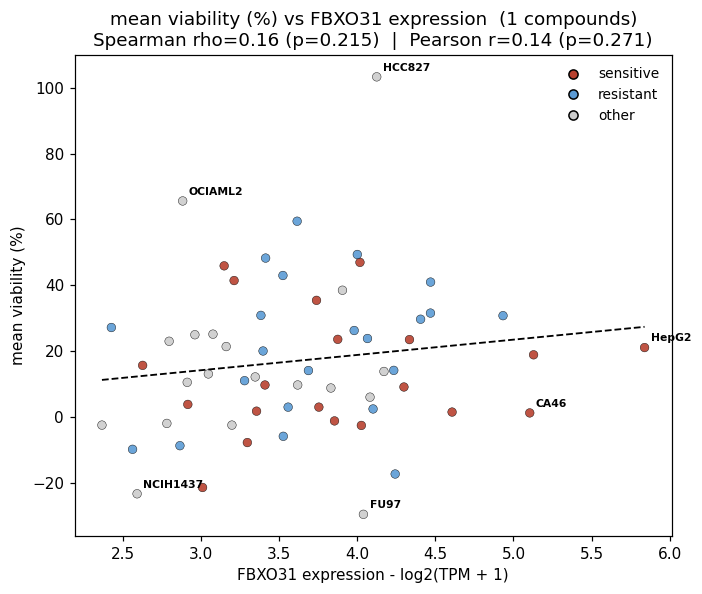

> 61 cell lines over 1 compounds | Spearman rho=0.161 p=0.215


In [100]:
## Scatter plot of cell sensitivity vs FBXO31 expression:
import importlib, python.cytotox_plots as cup; importlib.reload(cup)

METRIC    = 'viability'   # 'viability' or 'sensitivity'
COMPOUNDS = ['SRB-0005618'] # None # Low_cms # None # High_cms #            # None = all compounds in `mat`; or e.g. ['SRB-0004870', ...]

res = cup.plot_cytotox_vs_expression(
    mat, expr, gene='FBXO31',
    metric=METRIC, compounds=COMPOUNDS,
    group_label=label, n_label=6)
plt.tight_layout(); plt.show()
print(f'> {res["n"]} cell lines over {res["n_compounds"]} compounds | '
      f'Spearman rho={res["spearman"][0]:.3f} p={res["spearman"][1]:.3g}')


$$z_{g,c} = \frac{E_{g,c} - \overline{E_g}}{\mathrm{sd}(E_g)}$$

In [88]:
## Build the feature matrix: DepMap expression genes for our cell lines,
## aligned to sensitive/resistant labels. Two knobs:
##   COMPOUNDS  - which compounds' mean viability defines sensitivity (None = all in mat).
##   FBXO31_MIN - keep only cell lines that EXPRESS FBXO31 (log2(TPM+1) > this); the
##                FBXO31-sensitivity hypothesis is only meaningful where it is expressed.
import importlib, python.cytotox_plots as cup; importlib.reload(cup)

TOP_GENES  = 5000     # keep the TOP_GENES highest-VARIANCE genes (most informative); None = all ~19K
FBXO31_MIN = 0        # keep only cell lines with FBXO31 log2(TPM+1) > this (None = no filter)
COMPOUNDS  = None # ['SRB-0002230'] #       # compounds whose mean killing defines sensitive/resistant (None = all in mat)
SPLIT_FRAC = 1/4      # extreme split: top frac = sensitive, bottom frac = resistant, middle dropped (1/3 = tertile; 0.25 = quartiles; smaller = more extreme)

# (re)compute sensitive/resistant labels from the chosen compound set: keep the top and
# bottom SPLIT_FRAC of cell lines, drop the ambiguous middle. COMPOUNDS=None + frac=1/3
# reproduces the global `label` from the split cell.
y_all = cup.sensitivity_labels(mat, compounds=COMPOUNDS, method='tertile', frac=SPLIT_FRAC)

# keep cell lines that have BOTH expression and a (compound-derived) label
cells = [c for c in expr.index if c in y_all.index]

# FBXO31-expression filter
n_drop_fbxo = 0
if FBXO31_MIN is not None:
    keep        = expr.loc[cells, 'FBXO31'] > FBXO31_MIN
    n_drop_fbxo = int((~keep).sum())
    cells       = keep[keep].index.tolist()

X = expr.loc[cells]                       # rows = cell lines, cols = genes
y = y_all.loc[cells]                      # 'sensitive' / 'resistant'

# optionally reduce to the most-variable genes (variance taken across cell lines)
if TOP_GENES:
    top = X.var(axis=0).sort_values(ascending=False).head(TOP_GENES).index
    X = X[top]

ncmp = mat.shape[0] if COMPOUNDS is None else len([c for c in COMPOUNDS if c in mat.index])
print(f'> sensitivity from {ncmp} compounds {"(all)" if COMPOUNDS is None else "(selected)"} '
      f'-> {len(y_all)} labelled cell lines (extreme split, frac={SPLIT_FRAC:.3g})')
print(f'> feature matrix X: {X.shape[0]} cell lines x {X.shape[1]:,} genes '
      f'({"top-%d by variance" % TOP_GENES if TOP_GENES else "all genes"})')
if FBXO31_MIN is not None:
    print(f'> FBXO31 filter: kept lines with FBXO31 log2(TPM+1) > {FBXO31_MIN} '
          f'({n_drop_fbxo} labelled lines dropped below threshold)')
print(f'> labels: sensitive {int((y=="sensitive").sum())} | resistant {int((y=="resistant").sum())} '
      f'({len(y_all)-len(cells)} of {len(y_all)} labelled lines excluded — no expression and/or FBXO31 <= {FBXO31_MIN})')
X.iloc[:2, :4]


> sensitivity from 42 compounds (all) -> 34 labelled cell lines (extreme split, frac=0.25)
> feature matrix X: 33 cell lines x 5,000 genes (top-5000 by variance)
> FBXO31 filter: kept lines with FBXO31 log2(TPM+1) > 0 (0 labelled lines dropped below threshold)
> labels: sensitive 16 | resistant 17 (1 of 34 labelled lines excluded — no expression and/or FBXO31 <= 0)


,XAGE1A,KRT19,FABP1,VIM
CellLineName,,,,
THP1,10.196725,1.778209,0.000000,4.713146
MOLM13,9.355505,1.084064,0.389567,7.690766


> 35 genes x 33 cell lines, ranked by FBXO31 expression


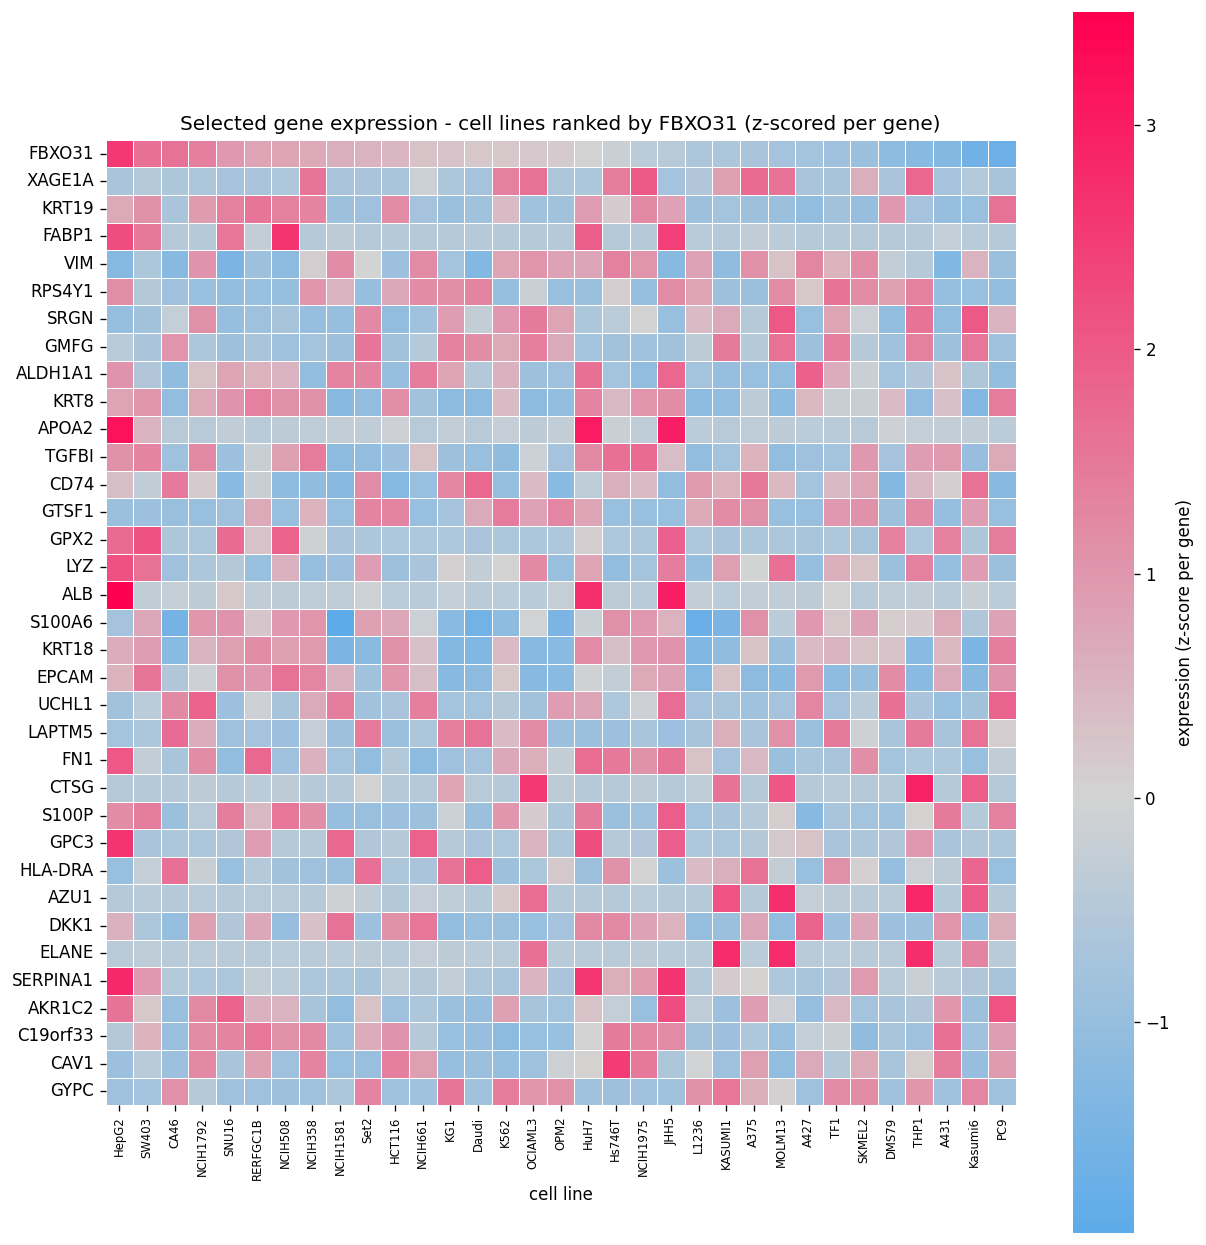

In [92]:
## Heatmap: selected genes x cell lines, coloured by expression (slide figure)
## Square-cell heatmap of N genes; columns RANKED by FBXO31 expression (high -> low), no
## sensitive/resistant split. Colours from the CMAP stops below.
import importlib, python.cytotox_plots as cup; importlib.reload(cup)
from matplotlib.colors import LinearSegmentedColormap

N_GENES     = 35      # how many genes (rows) to show
STANDARDIZE = True    # z-score each gene across cell lines (recommended for many genes); False = raw log2(TPM+1)
EXTRA_GENES = ['FBXO31']             # genes to always include / pin first
CMAP        = [ACTIVE_C, 'lightgray', SILENT_C]   # low -> mid -> high colour stops

# genes: top-variance across the displayed cell lines, FBXO31 pinned first
cl0  = list(X.index)
var  = expr.loc[cl0].var(axis=0).sort_values(ascending=False)
pins = [g for g in EXTRA_GENES if g in expr.columns]
HEATMAP_GENES = pins + [g for g in var.index if g not in pins][:max(0, N_GENES - len(pins))]

# cell lines (columns) ranked by FBXO31 expression, high -> low (no group split)
cells_ranked = expr.loc[cl0, 'FBXO31'].sort_values(ascending=False).index.tolist()
print(f'> {len(HEATMAP_GENES)} genes x {len(cells_ranked)} cell lines, ranked by FBXO31 expression')

cmap = LinearSegmentedColormap.from_list('CMAP', CMAP)
cup.plot_gene_expression_heatmap(
    expr, HEATMAP_GENES, cells=cells_ranked,
    group_label=None, cmap=cmap, center=(0 if STANDARDIZE else None),
    square=True, annot=False, standardize=STANDARDIZE)
plt.title('Selected gene expression - cell lines ranked by FBXO31'
          + (' (z-scored per gene)' if STANDARDIZE else '  log2(TPM+1)'))
plt.tight_layout(); plt.show()


> feature dim: (33, 5000)


  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:00<00:02,  1.84it/s]

-----------------------------------------
> Fold 1 Accuracy: 0.14, F1: 0.00, Roc_auc: 0.50, PR_auc: 0.91,
>> True negative (False negative):  1 ( 6 )
>> True positive (False positive):  0 ( 0 )


 40%|████      | 2/5 [00:01<00:01,  2.01it/s]

...

-----------------------------------------
> Fold 4 Accuracy: 0.50, F1: 0.00, Roc_auc: 0.67, PR_auc: 0.51,
>> True negative (False negative):  3 ( 3 )
>> True positive (False positive):  0 ( 0 )


100%|██████████| 5/5 [00:02<00:00,  1.85it/s]


-----------------------------------------
> Fold 5 Accuracy: 0.33, F1: 0.00, Roc_auc: 0.40, PR_auc: 0.12,
>> True negative (False negative):  2 ( 1 )
>> True positive (False positive):  0 ( 3 )

>>> Global accuracy: 0.42, F1: 0.24, ROC_AUC: 0.45, PR_AUC: 0.42


100%|██████████| 5/5 [00:00<00:00, 395.62it/s]


> XGB out-of-fold ROC-AUC = 0.452  |  naive baseline = 0.575  (chance 0.50)
  VERDICT: NOT predictive (near chance)


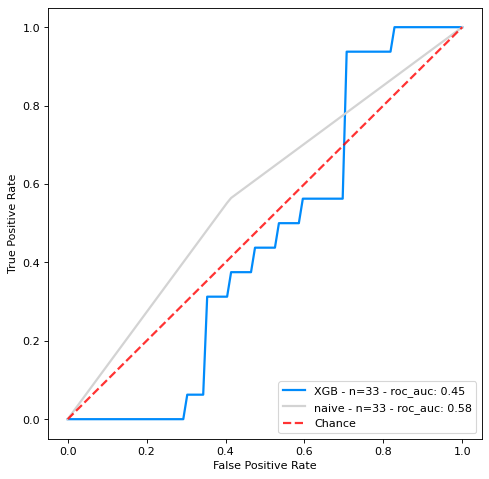

In [87]:
## Predict sensitive vs resistant — using the project K-fold classifier
## (ML_Class.run_K_Fold_Xval_Classification) with XGBoost, + a stratified naive baseline.
import warnings
warnings.filterwarnings('ignore', message=r'.*sklearn\.utils\.parallel\.delayed.*')
import ML_Class
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

# assemble ML_data: gene features + label (1=sensitive, 0=resistant) + cell-line ID
ML_data = X.copy()
ML_data['label']    = (y == 'sensitive').astype(int).values
ML_data['cellline'] = X.index
ML_data = ML_data.reset_index(drop=True)

params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05,
          'colsample_bytree': 1.0, 'min_child_weight': 1, 'scale_pos_weight': 1}
model = XGBClassifier(**params, n_jobs=-1, random_state=42)
trained_model, df_pred = ML_Class.run_K_Fold_Xval_Classification(
    ML_data, ID='cellline', model=model, folds=5,
    col_to_rm=['label', 'cellline'], v=True, ctf=0.5, impute_by_mean=False)

# Naive baseline: predicts class proportions => ROC AUC ~ 0.5 by construction.
naive_model = DummyClassifier(strategy='stratified', random_state=42)
_, df_pred_naive = ML_Class.run_K_Fold_Xval_Classification(
    ML_data, ID='cellline', model=naive_model, folds=5,
    col_to_rm=['label', 'cellline'], v=False, ctf=0.5, impute_by_mean=False)

auc_xgb   = roc_auc_score(df_pred['real_y'], df_pred['probas'])
auc_naive = roc_auc_score(df_pred_naive['real_y'], df_pred_naive['probas'])
print(f'\n> XGB out-of-fold ROC-AUC = {auc_xgb:.3f}  |  naive baseline = {auc_naive:.3f}  (chance 0.50)')
print('  VERDICT:', 'PREDICTIVE' if auc_xgb > 0.6 else 'NOT predictive (near chance)')

# nice ROC curve (project helper, same call as MS_TargetML) — df_pred has real_y/pred_y/probas
roc_df = ML_Class.plot_roc_curve(
    [df_pred, df_pred_naive],
    c=[ACTIVE_C, 'lightgrey'],
    l=['XGB', 'naive'],
    metric2show=['roc_auc'], dpi=80, legend=True,
)


In [46]:
## Leave-one-out CV (small n) — project ID-defined K-fold (ML_Class), XGBoost.
## Each fold holds out ONE cell line. Per-fold AUC is undefined with 1 test point,
## so we POOL all held-out predictions for the global ROC-AUC, and use a label-
## permutation null (the proper baseline for p>>n) instead of the noisy dummy.
import warnings
warnings.filterwarnings('ignore', message=r'.*sklearn\.utils\.parallel\.delayed.*')
import ML_Class
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

# ML_data: gene features + label + cell-line ID (rebuilt from X/y so cell is self-contained)
ML_data = X.copy()
ML_data['label']    = (y == 'sensitive').astype(int).values
ML_data['cellline'] = X.index
ML_data = ML_data.reset_index(drop=True)

params = {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05,
          'colsample_bytree': 1.0, 'min_child_weight': 1, 'scale_pos_weight': 1}

ids     = list(ML_data['cellline'])
ID_sets = [[[j for j in ids if j != i], [i]] for i in ids]      # leave-one-out splits

# model = RandomForestClassifier(n_estimators=100,n_jobs=8,random_state=0)
model = XGBClassifier(**params, n_jobs=8, random_state=42)

def _loo_auc(dfm):
    _, dp = ML_Class.K_fold_by_defined_IDs_Classification(
        dfm, ID='cellline', ID_sets=ID_sets,
        model=model,
        col_to_rm=['label', 'cellline'], v=False, ctf=0.5, impute_by_mean=False)
    return dp

df_loo  = _loo_auc(ML_data)
auc_loo = roc_auc_score(df_loo['real_y'], df_loo['probas'])
acc_loo = accuracy_score(df_loo['real_y'], df_loo['pred_y'])
print(f'> XGB LOO-CV (n={len(ids)} folds): pooled ROC-AUC = {auc_loo:.3f} | accuracy = {acc_loo:.3f}  (chance 0.50)')

  0%|          | 0/42 [00:00<?, ?it/s]

100%|██████████| 42/42 [00:19<00:00,  2.19it/s]

> XGB LOO-CV (n=42 folds): pooled ROC-AUC = 0.627 | accuracy = 0.548  (chance 0.50)


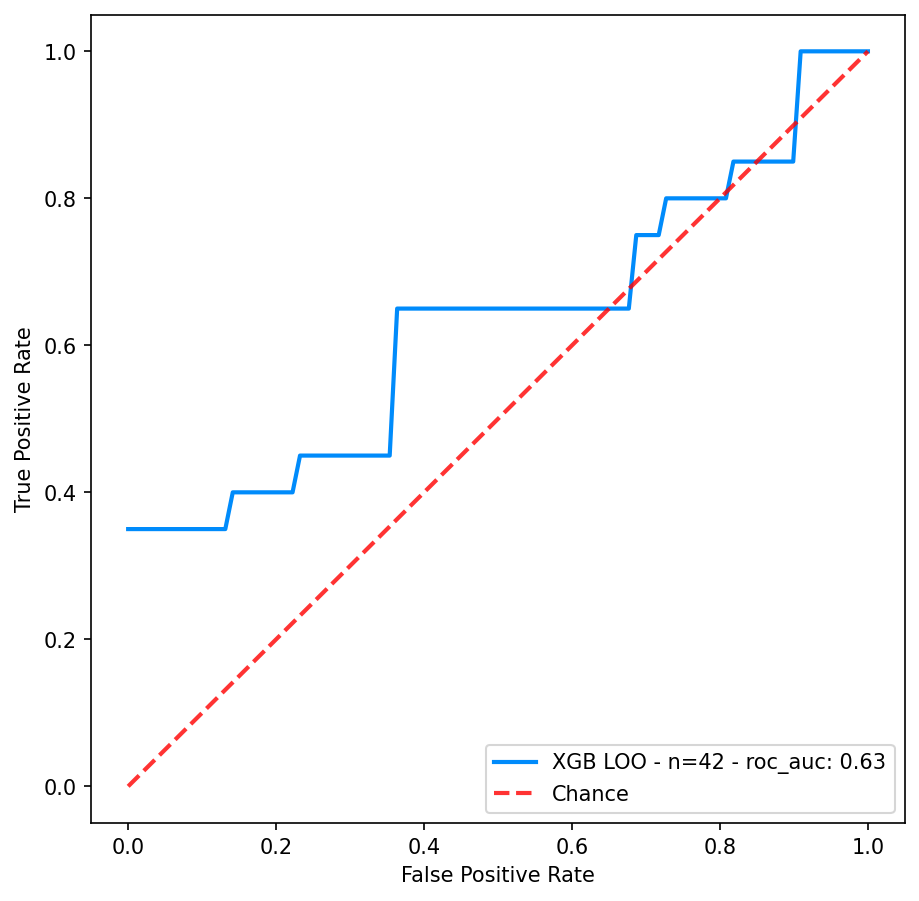

In [47]:
# nice ROC curve from the pooled LOO predictions (project helper, as in MS_TargetML)
roc_df = ML_Class.plot_roc_curve([df_loo], c=[active_c], l=['XGB LOO'],
                                 metric2show=['roc_auc'], dpi=150, legend=True)

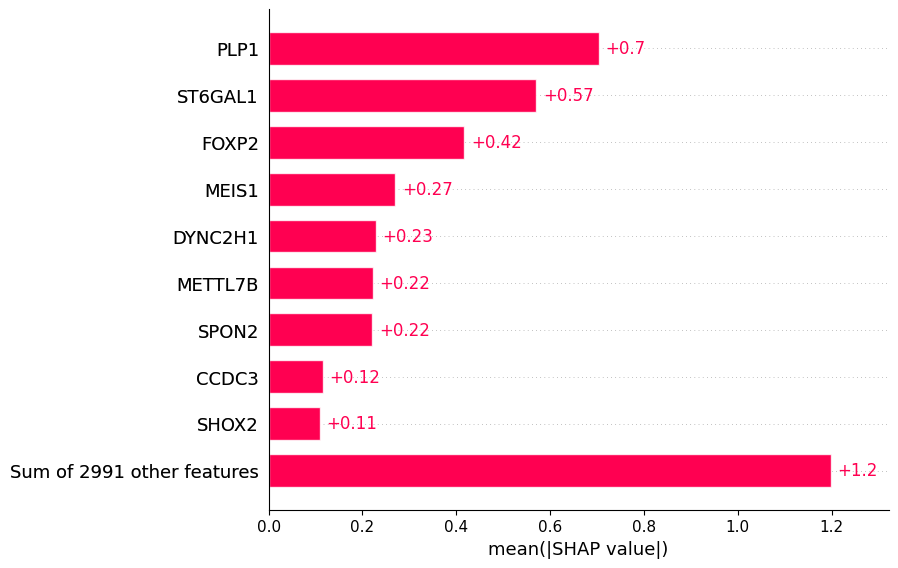

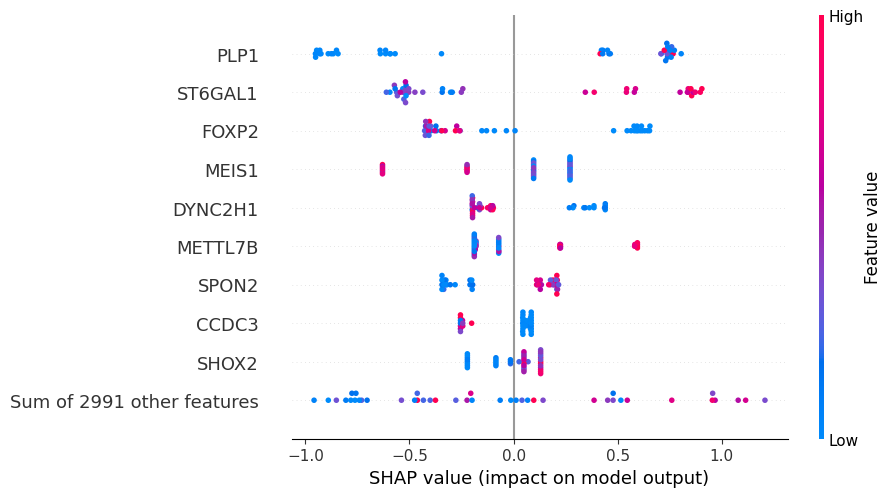

compound=CA46, p(active)=0.959


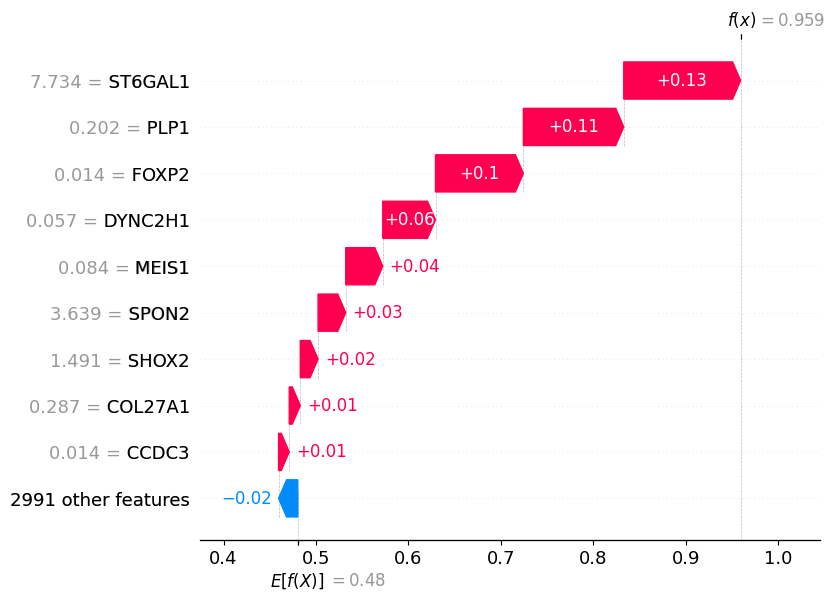

In [33]:
## SHAP analysis on final model:
## requires shap in the active env: pip install "shap<0.47"
## Trains XGB on ALL cell lines, then SHAP — global bar + beeswarm (which genes drive
## the sensitive/resistant call) + a per-cell-line waterfall.
## CAVEAT: out-of-fold this model is ~chance (see LOO permutation null), so these are
## the model's IN-SAMPLE drivers (likely overfit on n=42), NOT validated biomarkers —
## only trust them if the permutation null comes back significant.
import ML_Class
from xgboost import XGBClassifier

params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05,
          'colsample_bytree': 1.0, 'min_child_weight': 1, 'scale_pos_weight': 1}
yb = (y == 'sensitive').astype(int).values
final_model = XGBClassifier(**params, n_jobs=8, random_state=42).fit(X, yb)

shap_values, shap_p = ML_Class.shap_analysis_xgb(
    final_model, X,
    compound_ids=X.index.values,      # cell-line names (waterfall label)
    which='top', max_display=10,
)


In [48]:
# label-permutation null
rng = np.random.default_rng(0); N_PERM = 200   # need >=19 for p<0.05 to be possible; 99 -> p down to 0.01 (~30-40 min)
null = []
for _ in range(N_PERM):
    dfp = ML_data.copy(); dfp['label'] = rng.permutation(dfp['label'].values)
    null.append(roc_auc_score(*[ (d:=_loo_auc(dfp))['real_y'], d['probas'] ]))
null = np.array(null); pval = (1 + np.sum(null >= auc_loo)) / (1 + N_PERM)
print(f'> permutation null AUC = {null.mean():.3f} +/- {null.std():.3f}  p={pval:.3f}')
print('  VERDICT:', 'PREDICTIVE' if (auc_loo > 0.5 and pval < 0.05) else 'NOT predictive (LOO at chance)')

  0%|          | 0/42 [00:00<?, ?it/s]

100%|██████████| 42/42 [00:19<00:00,  2.20it/s]

> permutation null AUC = 0.466 +/- 0.179  p=0.209
  VERDICT: NOT predictive (LOO at chance)
